<a href="https://colab.research.google.com/github/sirrom/Intelligent-Cloud-Resource-Optimization-System/blob/main/Training_of_Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# What It Does
This section loads every library the lab depends on. NumPy handles all tensor operations, matrix multiplications, and gradient calculations. Pandas manages tabular datasets. Matplotlib and Seaborn produce all training curves, weight distribution plots, and decision boundary visualizations. Scikit-learn provides dataset generators and preprocessing utilities. The random seeds are fixed so every student running the lab gets identical results and can verify their outputs against the expected values.

In [ ]:
# ============================================================
#  NEURAL NETWORK TRAINING LAB — Full Executable Version
#  Run this entire file top to bottom
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.animation as animation
from matplotlib.patches import FancyArrowPatch
import seaborn as sns
from sklearn.datasets import make_moons, make_circles, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")

# ── Reproducibility ─────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ── Plot style ───────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor"  : "white",
    "axes.facecolor"    : "#f9f9f9",
    "axes.spines.top"   : False,
    "axes.spines.right" : False,
    "font.family"       : "DejaVu Sans",
    "font.size"         : 11,
    "axes.titlesize"    : 13,
    "axes.titleweight"  : "bold",
})

COLORS = ["#e74c3c","#3498db","#2ecc71","#f39c12",
          "#9b59b6","#1abc9c","#e67e22","#34495e"]

print("✅ Imports loaded successfully")
print("=" * 55)

✅ Imports loaded successfully


## Part 1 — Activation Functions
# What It Does
Activation functions introduce non-linearity into the network. Without them, stacking multiple layers is mathematically equivalent to a single linear transformation, meaning the network cannot learn any non-linear pattern regardless of its depth. Each activation function has a formula, a derivative used during backpropagation, and specific strengths and weaknesses.

The Sigmoid function squashes any real number into the range zero to one, making it historically popular for binary output neurons. Its derivative is sigma times one minus sigma, which is computationally convenient but approaches zero for very large or very small inputs, causing the vanishing gradient problem in deep networks.

The Hyperbolic Tangent function squashes inputs into the range negative one to positive one. It is zero-centered, meaning positive and negative activations are equally likely, which helps weight updates be more balanced than Sigmoid. Its derivative is one minus tanh squared, but it still suffers from vanishing gradients at saturation.

The Rectified Linear Unit, or ReLU, returns the input unchanged if positive and returns zero if negative. Its derivative is exactly one for all positive inputs and zero for negative inputs, which completely eliminates the vanishing gradient problem for positive activations. ReLU is the default choice for hidden layers in modern networks. Its main failure mode is the dying ReLU problem, where a neuron whose input is always negative produces zero gradient and never recovers.

Leaky ReLU solves the dying ReLU problem by returning a small negative slope, typically 0.01 times the input, instead of zero for negative values, ensuring the gradient is never exactly zero.

The Softmax function converts a vector of raw scores into a probability distribution summing to one, making it the standard choice for multi-class output layers.

In [ ]:
# ============================================================
#  BLOCK 2: ACTIVATION FUNCTIONS
# ============================================================

class Activation:
    @staticmethod
    def sigmoid(z):
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def sigmoid_derivative(z):
        s = Activation.sigmoid(z)
        return s * (1.0 - s)

    @staticmethod
    def tanh(z):
        return np.tanh(z)

    @staticmethod
    def tanh_derivative(z):
        return 1.0 - np.tanh(z) ** 2

    @staticmethod
    def relu(z):
        return np.maximum(0.0, z)

    @staticmethod
    def relu_derivative(z):
        return (z > 0).astype(float)

    @staticmethod
    def leaky_relu(z, alpha=0.01):
        return np.where(z > 0, z, alpha * z)

    @staticmethod
    def leaky_relu_derivative(z, alpha=0.01):
        return np.where(z > 0, 1.0, alpha)

    @staticmethod
    def softmax(z):
        z_s = z - np.max(z, axis=1, keepdims=True)
        e   = np.exp(z_s)
        return e / np.sum(e, axis=1, keepdims=True)

    @staticmethod
    def linear(z):
        return z

    @staticmethod
    def linear_derivative(z):
        return np.ones_like(z)

    @staticmethod
    def get(name):
        r = {
            "sigmoid"    : (Activation.sigmoid,
                            Activation.sigmoid_derivative),
            "tanh"       : (Activation.tanh,
                            Activation.tanh_derivative),
            "relu"       : (Activation.relu,
                            Activation.relu_derivative),
            "leaky_relu" : (Activation.leaky_relu,
                            Activation.leaky_relu_derivative),
            "softmax"    : (Activation.softmax, None),
            "linear"     : (Activation.linear,
                            Activation.linear_derivative),
        }
        if name not in r:
            raise ValueError(f"Unknown activation: {name}")
        return r[name]


# ── VISUALIZATION 1: Activation Functions ────────────────────
def visualize_activations():
    print("\n📊 VISUALIZATION 1: Activation Functions")
    print("-" * 45)

    z = np.linspace(-5, 5, 400)
    data = [
        ("Sigmoid",    Activation.sigmoid(z),
                       Activation.sigmoid_derivative(z),
                       "Squashes to (0,1). Used for binary output.\n"
                       "Problem: gradient → 0 when |z| > 4"),
        ("Tanh",       Activation.tanh(z),
                       Activation.tanh_derivative(z),
                       "Squashes to (-1,1). Zero-centered.\n"
                       "Still suffers from vanishing gradients"),
        ("ReLU",       Activation.relu(z),
                       Activation.relu_derivative(z),
                       "max(0,z). Gradient = 1 for z>0.\n"
                       "Default hidden layer choice. Can die."),
        ("Leaky ReLU", Activation.leaky_relu(z),
                       Activation.leaky_relu_derivative(z),
                       "Fixes dying ReLU.\n"
                       "Small slope (0.01) for z < 0"),
    ]

    fig = plt.figure(figsize=(20, 10))
    fig.suptitle("⚡ ACTIVATION FUNCTIONS — What Each Neuron Does to Its Input",
                 fontsize=16, fontweight='bold', y=1.01)

    for i, (name, fz, dfz, note) in enumerate(data):
        # Activation plot
        ax1 = fig.add_subplot(3, 4, i + 1)
        ax1.plot(z, fz, lw=3, color=COLORS[i])
        ax1.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax1.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax1.fill_between(z, fz, alpha=0.15, color=COLORS[i])
        ax1.set_title(f"f(z) — {name}", fontsize=12)
        ax1.set_xlabel("Input z"); ax1.set_ylabel("Output f(z)")
        ax1.grid(True, alpha=0.25)

        # Derivative plot
        ax2 = fig.add_subplot(3, 4, i + 5)
        ax2.plot(z, dfz, lw=3, color=COLORS[i], ls='--')
        ax2.axhline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax2.axvline(0, color='gray', lw=0.8, ls='--', alpha=0.6)
        ax2.fill_between(z, dfz, alpha=0.15, color=COLORS[i])
        ax2.set_title(f"f'(z) — {name} Derivative", fontsize=12)
        ax2.set_xlabel("Input z"); ax2.set_ylabel("Gradient f'(z)")
        ax2.grid(True, alpha=0.25)

        # Text note
        ax3 = fig.add_subplot(3, 4, i + 9)
        ax3.axis('off')
        ax3.text(0.5, 0.5, note,
                 ha='center', va='center',
                 fontsize=10,
                 bbox=dict(boxstyle='round,pad=0.6',
                           facecolor=COLORS[i],
                           alpha=0.15,
                           edgecolor=COLORS[i]),
                 transform=ax3.transAxes)
        ax3.set_title("📝 Key Points", fontsize=11)

    plt.tight_layout()
    plt.savefig("viz1_activations.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → viz1_activations.png")


print("✅ Activation class ready")

✅ Activation class ready


# Part 2 — Loss Functions
# What It Does
The loss function measures how wrong the network's predictions are on each training example. It converts the raw prediction error into a single scalar number that the optimizer can minimize. The choice of loss function must match the task type.

Binary Cross-Entropy is used for binary classification where the output is a single probability. It equals negative the mean of y times log of y-hat plus one minus y times log of one minus y-hat. The logarithm heavily penalizes confident wrong predictions, which forces the network to produce well-calibrated probabilities rather than just getting the direction right.

Categorical Cross-Entropy is the multi-class generalization, computing the negative log-probability assigned to the true class. It is almost always paired with a Softmax output layer. Together, Softmax and Cross-Entropy have a beautifully simple gradient: the gradient with respect to the pre-Softmax scores is simply the predicted probability minus the one-hot true label.

Mean Squared Error is the standard loss for regression problems. It penalizes large errors quadratically, meaning an error of 10 is penalized 100 times more than an error of 1.

In [ ]:
# ============================================================
#  BLOCK 4: LOSS FUNCTIONS
# ============================================================

class Loss:
    @staticmethod
    def binary_crossentropy(y_true, y_pred):
        eps    = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(y_pred) +
                        (1 - y_true) * np.log(1 - y_pred))

    @staticmethod
    def binary_crossentropy_grad(y_true, y_pred):
        eps    = 1e-12
        y_pred = np.clip(y_pred, eps, 1 - eps)
        return (-(y_true / y_pred) +
                (1 - y_true) / (1 - y_pred)) / len(y_true)

    @staticmethod
    def categorical_crossentropy(y_true, y_pred):
        eps    = 1e-12
        y_pred = np.clip(y_pred, eps, 1.0)
        return -np.mean(np.sum(y_true * np.log(y_pred), axis=1))

    @staticmethod
    def categorical_crossentropy_grad(y_true, y_pred):
        return (y_pred - y_true) / len(y_true)

    @staticmethod
    def mse(y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

    @staticmethod
    def mse_grad(y_true, y_pred):
        return 2.0 * (y_pred - y_true) / len(y_true)

    @staticmethod
    def get(name):
        r = {
            'binary_crossentropy'     : (
                Loss.binary_crossentropy,
                Loss.binary_crossentropy_grad),
            'categorical_crossentropy': (
                Loss.categorical_crossentropy,
                Loss.categorical_crossentropy_grad),
            'mse': (Loss.mse, Loss.mse_grad),
        }
        if name not in r:
            raise ValueError(f"Unknown loss: {name}")
        return r[name]


print("✅ Loss class ready")

✅ Loss class ready


# Part 3 — Weight Initialization
# What It Does
How weights are initialized before training begins has a profound impact on whether the network converges, how fast it converges, and how good the final solution is. Poor initialization can cause the gradients to vanish or explode in the very first backward pass, before the optimizer has had any chance to improve the weights.

Zero initialization fails completely because all neurons in every layer compute identical outputs and receive identical gradients, meaning they all update to the same values and the network never develops specialized neurons. This symmetry-breaking problem means that a 100-neuron layer with zero initialization behaves identically to a single-neuron layer.

Random initialization with small values from a uniform or normal distribution breaks symmetry but can cause vanishing or exploding activations if the variance is not calibrated to the layer size.

Xavier initialization, also called Glorot initialization, sets the weight variance to two divided by the sum of the fan-in and fan-out of the layer. This keeps the variance of activations and gradients approximately constant across layers when using Sigmoid or Tanh activations.

He initialization sets the variance to two divided by the fan-in only, which is the correct scaling for ReLU activations because ReLU zeros out half its inputs, effectively halving the variance of each layer's activations.

In [ ]:
# ============================================================
#  BLOCK 3: WEIGHT INITIALIZATION
# ============================================================

class Initializer:
    @staticmethod
    def zeros(fan_in, fan_out):
        return np.zeros((fan_in, fan_out)), np.zeros((1, fan_out))

    @staticmethod
    def random_small(fan_in, fan_out, scale=0.01):
        return (np.random.randn(fan_in, fan_out) * scale,
                np.zeros((1, fan_out)))

    @staticmethod
    def xavier(fan_in, fan_out):
        lim = np.sqrt(6.0 / (fan_in + fan_out))
        return (np.random.uniform(-lim, lim, (fan_in, fan_out)),
                np.zeros((1, fan_out)))

    @staticmethod
    def xavier_normal(fan_in, fan_out):
        std = np.sqrt(2.0 / (fan_in + fan_out))
        return (np.random.randn(fan_in, fan_out) * std,
                np.zeros((1, fan_out)))

    @staticmethod
    def he(fan_in, fan_out):
        std = np.sqrt(2.0 / fan_in)
        return (np.random.randn(fan_in, fan_out) * std,
                np.zeros((1, fan_out)))

    @staticmethod
    def he_uniform(fan_in, fan_out):
        lim = np.sqrt(6.0 / fan_in)
        return (np.random.uniform(-lim, lim, (fan_in, fan_out)),
                np.zeros((1, fan_out)))

    @staticmethod
    def get(name):
        r = {
            'zeros'        : Initializer.zeros,
            'random_small' : Initializer.random_small,
            'xavier'       : Initializer.xavier,
            'xavier_normal': Initializer.xavier_normal,
            'he'           : Initializer.he,
            'he_uniform'   : Initializer.he_uniform,
        }
        if name not in r:
            raise ValueError(f"Unknown init: {name}")
        return r[name]

    @staticmethod
    def auto(activation_name):
        if activation_name in {'relu', 'leaky_relu'}:
            return 'he'
        return 'xavier'


# ── VISUALIZATION 2: Initialization Effect ───────────────────
def visualize_initialization():
    print("\n📊 VISUALIZATION 2: Weight Initialization Strategies")
    print("-" * 50)

    strategies = {
        'Zeros'        : Initializer.zeros,
        'Random Small' : Initializer.random_small,
        'Xavier'       : Initializer.xavier,
        'He'           : Initializer.he,
    }
    n_layers = 6
    fan      = 128
    x0       = np.random.randn(500, fan)

    fig, axes = plt.subplots(2, 4, figsize=(20, 9))
    fig.suptitle("🔧 WEIGHT INITIALIZATION — How Starting Values "
                 "Affect Signal Flow Through 6 Layers",
                 fontsize=14, fontweight='bold')

    for col, (name, fn) in enumerate(strategies.items()):
        var_tanh, var_relu = [], []
        a_t, a_r = x0.copy(), x0.copy()

        for _ in range(n_layers):
            W, _ = fn(fan, fan)
            a_t  = np.tanh(a_t @ W)
            a_r  = np.maximum(0, a_r @ W)
            var_tanh.append(np.var(a_t))
            var_relu.append(np.var(a_r))

        # Tanh variance
        ax = axes[0, col]
        ax.plot(range(1, n_layers+1), var_tanh,
                'o-', lw=2.5, ms=8, color=COLORS[col])
        ax.axhline(1.0, color='black', ls=':', lw=1.5)
        ax.set_title(f"{name}\n(Tanh Network)")
        ax.set_xlabel("Layer Depth")
        ax.set_ylabel("Activation Variance")
        ax.grid(True, alpha=0.3)
        ax.text(0.97, 0.95, "─── ideal = 1.0",
                transform=ax.transAxes, ha='right',
                fontsize=9, color='black')

        # ReLU variance
        ax2 = axes[1, col]
        ax2.plot(range(1, n_layers+1), var_relu,
                 's-', lw=2.5, ms=8, color=COLORS[col])
        ax2.axhline(1.0, color='black', ls=':', lw=1.5)
        ax2.set_title(f"{name}\n(ReLU Network)")
        ax2.set_xlabel("Layer Depth")
        ax2.set_ylabel("Activation Variance")
        ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("viz2_initialization.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → viz2_initialization.png")
    print("  📌 Student note: Xavier keeps variance ≈ 1 for Tanh;")
    print("     He keeps variance ≈ 1 for ReLU.")


print("✅ Initializer class ready")

✅ Initializer class ready


# Part 4 — Optimizers
# What It Does
The optimizer takes the gradients computed by backpropagation and uses them to update the weights in a direction that reduces the loss. Different optimizers make different assumptions about the loss landscape and use different strategies to navigate it efficiently.

Vanilla Stochastic Gradient Descent subtracts a fixed fraction of the gradient from each weight at every step. The fraction is the learning rate, which is the most important hyperparameter in neural network training. A learning rate too large causes the loss to oscillate or diverge. A learning rate too small causes training to proceed glacially slowly.

SGD with Momentum accumulates a velocity vector that builds up in directions of consistent gradient and dampens oscillations in directions where the gradient keeps changing sign. The momentum term, typically set to 0.9, means each update carries 90 percent of the previous velocity, making training significantly more stable and faster in practice.

RMSProp divides the learning rate for each weight by the running average of the magnitude of recent gradients for that weight. Weights whose gradients have been consistently large get a smaller effective learning rate, and weights whose gradients have been small get a larger effective learning rate. This per-parameter adaptive learning rate solves the problem of choosing a single learning rate that works for all weights simultaneously.

Adam combines the benefits of Momentum and RMSProp. It maintains both a running average of gradients (first moment) and a running average of squared gradients (second moment), and applies bias correction to account for the fact that both averages start at zero. Adam is the default optimizer for most neural network training tasks because it works well across a wide range of architectures and datasets with minimal hyperparameter tuning.

In [ ]:
# ============================================================
#  BLOCK 5: OPTIMIZERS
# ============================================================

class SGD:
    def __init__(self, learning_rate=0.01, momentum=0.0):
        self.lr       = learning_rate
        self.momentum = momentum
        self.velocity = {}

    def update(self, params, grads):
        for k in params:
            if k not in self.velocity:
                self.velocity[k] = np.zeros_like(params[k])
            self.velocity[k] = (self.momentum * self.velocity[k]
                                + self.lr * grads[k])
            params[k] = params[k] - self.velocity[k]
        return params


class RMSProp:
    def __init__(self, learning_rate=0.001, beta=0.9, eps=1e-8):
        self.lr    = learning_rate
        self.beta  = beta
        self.eps   = eps
        self.cache = {}

    def update(self, params, grads):
        for k in params:
            if k not in self.cache:
                self.cache[k] = np.zeros_like(params[k])
            self.cache[k] = (self.beta * self.cache[k] +
                             (1 - self.beta) * grads[k] ** 2)
            params[k] = params[k] - (
                self.lr / (np.sqrt(self.cache[k]) + self.eps)
                * grads[k])
        return params


class Adam:
    def __init__(self, learning_rate=0.001,
                 beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr    = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps   = eps
        self.m     = {}
        self.v     = {}
        self.t     = 0

    def update(self, params, grads):
        self.t += 1
        for k in params:
            if k not in self.m:
                self.m[k] = np.zeros_like(params[k])
                self.v[k] = np.zeros_like(params[k])
            self.m[k] = (self.beta1 * self.m[k] +
                         (1 - self.beta1) * grads[k])
            self.v[k] = (self.beta2 * self.v[k] +
                         (1 - self.beta2) * grads[k] ** 2)
            m_hat      = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat      = self.v[k] / (1 - self.beta2 ** self.t)
            params[k]  = params[k] - (
                self.lr * m_hat / (np.sqrt(v_hat) + self.eps))
        return params


def get_optimizer(name, lr):
    opts = {
        'sgd'         : SGD(lr, momentum=0.0),
        'sgd_momentum': SGD(lr, momentum=0.9),
        'rmsprop'     : RMSProp(lr),
        'adam'        : Adam(lr),
    }
    if name not in opts:
        raise ValueError(f"Unknown optimizer: {name}")
    return opts[name]


print("✅ Optimizer classes ready (SGD, RMSProp, Adam)")

✅ Optimizer classes ready (SGD, RMSProp, Adam)


# Part 5 — Dense Layer
# What It Does
The Dense layer, also called a fully connected layer, is the fundamental building block of a neural network. Every neuron in a Dense layer is connected to every neuron in the previous layer. The layer performs a linear transformation followed by a non-linear activation function.

The forward pass computes the pre-activation value z by multiplying the input matrix by the weight matrix and adding the bias vector, producing z equals X times W plus b. It then applies the activation function to produce the output a equals activation of z. Both z and the input X are cached because the backward pass needs them to compute gradients.

The backward pass receives the gradient of the loss with respect to the layer's output and uses the chain rule to compute three things. First, the gradient with respect to z, computed by multiplying the upstream gradient by the derivative of the activation function at z. Second, the gradient with respect to the weights, computed as X transposed times delta-z, which is the contribution of this layer's weights to the total loss. Third, the gradient with respect to the input, computed as delta-z times W transposed, which is passed backward to the previous layer. The gradient with respect to the bias is simply the column-wise sum of delta-z across all training examples.

In [ ]:
class DenseLayer:
    def __init__(self, input_dim, output_dim,
                 activation='relu', init=None):
        self.input_dim  = input_dim
        self.output_dim = output_dim
        self.act_name   = activation
        self.act_fn, self.act_deriv = Activation.get(activation)

        if init is None:
            init = Initializer.auto(activation)
        self.W, self.b  = Initializer.get(init)(input_dim, output_dim)

        self.X = self.z = self.a = None
        self.dW = self.db = None

    def forward(self, X, training=True):
        self.X = X
        self.z = X @ self.W + self.b
        self.a = (Activation.softmax(self.z)
                  if self.act_name == 'softmax'
                  else self.act_fn(self.z))
        return self.a

    def backward(self, d_out):
        N  = self.X.shape[0]
        dz = (d_out if self.act_name == 'softmax'
              else d_out * self.act_deriv(self.z))
        self.dW = self.X.T @ dz / N
        self.db = dz.sum(axis=0, keepdims=True) / N
        return dz @ self.W.T

    def get_params(self, prefix=""):    return {f"{prefix}W": self.W, f"{prefix}b": self.b}
    def get_grads(self, prefix=""):     return {f"{prefix}W": self.dW, f"{prefix}b": self.db}
    def set_params(self, p, prefix=""): self.W = p[f"{prefix}W"]; self.b = p[f"{prefix}b"]
    def __repr__(self):
        return (f"Dense({self.input_dim}→{self.output_dim}, "
                f"act='{self.act_name}')")


class Dropout:
    def __init__(self, rate=0.5):
        self.rate     = rate
        self.mask     = None
        self.training = True

    def forward(self, X, training=True):
        self.training = training
        if not training or self.rate == 0:
            return X
        keep = 1.0 - self.rate
        self.mask = (np.random.rand(*X.shape) < keep).astype(float) / keep
        return X * self.mask

    def backward(self, d_out):
        if not self.training or self.rate == 0:
            return d_out
        return d_out * self.mask

    def get_params(self, prefix=""):    return {}
    def get_grads(self, prefix=""):     return {}
    def set_params(self, p, prefix=""): pass
    def __repr__(self): return f"Dropout(rate={self.rate})"


class BatchNorm:
    def __init__(self, dim, momentum=0.9, eps=1e-8):
        self.gamma        = np.ones((1, dim))
        self.beta         = np.zeros((1, dim))
        self.momentum     = momentum
        self.eps          = eps
        self.running_mean = np.zeros((1, dim))
        self.running_var  = np.ones((1, dim))
        self.cache        = {}
        self.dgamma = self.dbeta = None

    def forward(self, X, training=True):
        if training:
            mu     = X.mean(0, keepdims=True)
            var    = X.var(0,  keepdims=True)
            X_norm = (X - mu) / np.sqrt(var + self.eps)
            self.running_mean = (self.momentum * self.running_mean
                                 + (1 - self.momentum) * mu)
            self.running_var  = (self.momentum * self.running_var
                                 + (1 - self.momentum) * var)
            self.cache = {'X': X, 'X_norm': X_norm,
                          'mu': mu, 'var': var}
        else:
            X_norm = ((X - self.running_mean) /
                      np.sqrt(self.running_var + self.eps))
        return self.gamma * X_norm + self.beta

    def backward(self, d_out):
        X, X_norm = self.cache['X'], self.cache['X_norm']
        mu,   var = self.cache['mu'],  self.cache['var']
        N         = X.shape[0]
        self.dgamma = (d_out * X_norm).sum(0, keepdims=True)
        self.dbeta  = d_out.sum(0, keepdims=True)
        dX_norm = d_out * self.gamma
        dvar    = (-0.5 * dX_norm * (X - mu) *
                   (var + self.eps) ** -1.5).sum(0, keepdims=True)
        dmu     = ((-dX_norm / np.sqrt(var + self.eps)
                    ).sum(0, keepdims=True) +
                   dvar * (-2 * (X - mu)).mean(0, keepdims=True))
        return (dX_norm / np.sqrt(var + self.eps) +
                dvar * 2 * (X - mu) / N + dmu / N)

    def get_params(self, prefix=""):    return {f"{prefix}gamma": self.gamma, f"{prefix}beta": self.beta}
    def get_grads(self, prefix=""):     return {f"{prefix}gamma": self.dgamma, f"{prefix}beta": self.dbeta}
    def set_params(self, p, prefix=""): self.gamma = p[f"{prefix}gamma"]; self.beta = p[f"{prefix}beta"]
    def __repr__(self): return f"BatchNorm(dim={self.gamma.shape[1]})"

# Part 7 — Neural Network (Full Model)
# What It Does
The NeuralNetwork class assembles individual layers into a complete model and implements the full training pipeline including forward propagation, backpropagation, mini-batch gradient descent, learning rate scheduling, and early stopping.

The forward pass method iterates through all layers in sequence, feeding the output of each layer as the input to the next. During training, dropout layers are active. During inference, they are disabled. The final layer output is the network's prediction.

The backward pass method iterates through the layers in reverse order, passing the upstream gradient through each layer's backward method. The gradient starts as the derivative of the loss with respect to the network's output and is progressively transformed by each layer until it reaches the input. At each layer, the weight and bias gradients are computed and stored for the optimizer to use.

The train method implements full mini-batch training with configurable batch size, number of epochs, validation split, and early stopping patience. At the end of each epoch it records training and validation loss and accuracy, enabling the learning curve visualization.

In [ ]:
class NeuralNetwork:
    def __init__(self, layer_configs,
                 loss='binary_crossentropy',
                 optimizer='adam',
                 learning_rate=0.001,
                 l2_lambda=0.0):
        self.loss_name = loss
        self.l2_lambda = l2_lambda
        self.layers    = []
        self.history   = defaultdict(list)
        self.loss_fn, self.loss_grad_fn = Loss.get(loss)
        self._build(layer_configs)
        self.optimizer = get_optimizer(optimizer, learning_rate)

    def _build(self, configs):
        for cfg in configs:
            t = cfg['type'].lower()
            if t == 'dense':
                self.layers.append(DenseLayer(
                    cfg['input_dim'], cfg['units'],
                    cfg.get('activation', 'relu'),
                    cfg.get('init', None)))
            elif t == 'dropout':
                self.layers.append(Dropout(cfg.get('rate', 0.5)))
            elif t == 'batchnorm':
                self.layers.append(BatchNorm(cfg['dim']))
            else:
                raise ValueError(f"Unknown layer type: {t}")

    def forward(self, X, training=True):
        out = X
        for layer in self.layers:
            out = layer.forward(out, training=training)
        return out

    def backward(self, y_true, y_pred):
        grad = self.loss_grad_fn(y_true, y_pred)
        for layer in reversed(self.layers):
            grad = layer.backward(grad)

    def _loss(self, y_true, y_pred):
        loss = self.loss_fn(y_true, y_pred)
        if self.l2_lambda > 0:
            loss += 0.5 * self.l2_lambda * sum(
                np.sum(l.W**2) for l in self.layers
                if hasattr(l, 'W'))
        return loss

    def _update(self):
        all_params = {}
        all_grads  = {}
        for i, layer in enumerate(self.layers):
            prefix = f"layer{i}_"
            p = layer.get_params(prefix)
            g = layer.get_grads(prefix)
            if not p:
                continue
            if self.l2_lambda > 0:
                wk = f"{prefix}W"
                if wk in g and g[wk] is not None:
                    g[wk] = g[wk] + self.l2_lambda * p[wk]
            all_params.update(p)
            all_grads.update(g)
        updated = self.optimizer.update(all_params, all_grads)
        for i, layer in enumerate(self.layers):
            prefix = f"layer{i}_"
            if not layer.get_params(prefix):
                continue
            layer.set_params(updated, prefix)

    def predict(self, X):
        return self.forward(X, training=False)

    def predict_classes(self, X, threshold=0.5):
        p = self.predict(X)
        if p.shape[1] == 1:
            return (p >= threshold).astype(int).flatten()
        return np.argmax(p, axis=1)

    def _acc(self, y_true, y_pred):
        if y_pred.shape[1] == 1:
            return float(np.mean(
                (y_pred >= 0.5).astype(int).flatten() ==
                y_true.flatten().astype(int)))
        return float(np.mean(
            np.argmax(y_pred, 1) == np.argmax(y_true, 1)))

    def _snap(self):
        return {i: {k: v.copy() for k, v in l.get_params(f"layer{i}_").items()}
                for i, l in enumerate(self.layers)
                if l.get_params(f"layer{i}_")}

    def _restore(self, snap):
        for i, l in enumerate(self.layers):
            if i in snap:
                l.set_params(snap[i], prefix=f"layer{i}_")

    def train(self, X_train, y_train,
              epochs=100, batch_size=32,
              X_val=None, y_val=None,
              lr_schedule=None,
              early_stopping_patience=None,
              verbose=True):

        N          = len(X_train)
        best_vloss = np.inf
        pat_ctr    = 0
        best_w     = None
        init_lr    = self.optimizer.lr

        for ep in range(epochs):

            # Learning rate schedule
            if lr_schedule == 'step' and ep > 0 and ep % 20 == 0:
                self.optimizer.lr *= 0.5
            elif lr_schedule == 'cosine':
                self.optimizer.lr = (0.5 * init_lr *
                    (1 + np.cos(np.pi * ep / epochs)))

            # Shuffle + mini-batch loop
            idx = np.random.permutation(N)
            bl  = []
            for s in range(0, N, batch_size):
                Xb = X_train[idx[s:s+batch_size]]
                yb = y_train[idx[s:s+batch_size]]
                yp = self.forward(Xb, training=True)
                bl.append(self._loss(yb, yp))
                self.backward(yb, yp)
                self._update()

            # Epoch metrics
            tl = float(np.mean(bl))
            tp = self.predict(X_train)
            ta = self._acc(y_train, tp)
            self.history['train_loss'].append(tl)
            self.history['train_acc'].append(ta)

            vl = va = None
            if X_val is not None:
                vp = self.predict(X_val)
                vl = float(self._loss(y_val, vp))
                va = self._acc(y_val, vp)
                self.history['val_loss'].append(vl)
                self.history['val_acc'].append(va)

                # Early stopping
                if early_stopping_patience:
                    if vl < best_vloss - 1e-4:
                        best_vloss = vl
                        pat_ctr    = 0
                        best_w     = self._snap()
                    else:
                        pat_ctr += 1
                    if pat_ctr >= early_stopping_patience:
                        if verbose:
                            print(f"  ⏹  Early stop @ epoch {ep+1}")
                        if best_w:
                            self._restore(best_w)
                        break

            if verbose and (ep + 1) % 10 == 0:
                vs = (f" | val_loss={vl:.4f} val_acc={va:.4f}"
                      if vl is not None else "")
                print(f"  Ep {ep+1:4d}/{epochs} | "
                      f"loss={tl:.4f} acc={ta:.4f}{vs}")
        return self

    def summary(self):
        print("\n" + "=" * 55)
        print("  NEURAL NETWORK ARCHITECTURE")
        print("=" * 55)
        total = 0
        for i, l in enumerate(self.layers):
            if isinstance(l, DenseLayer):
                p = l.W.size + l.b.size
                total += p
                print(f"  Layer {i+1}: {l}  (Input: {l.input_dim}, Output: {l.output_dim}) [{p:,} params]")
            else:
                print(f"  Layer {i+1}: {l}")
        print("-" * 55)
        print(f"  Total trainable parameters: {total:,}")
        print("=" * 55 + "\n")

# Part 8 — Visualization Suite
# What It Does
The visualization suite translates the numerical training process into interpretable charts that reveal how and why the network is learning or failing to learn.

The learning curve plot shows training and validation loss and accuracy over epochs. A healthy learning curve shows both losses decreasing together, with validation loss slightly above training loss. A large gap between training and validation loss indicates overfitting. A curve where both losses remain high indicates underfitting. The point where validation loss stops improving and begins to increase is where early stopping should trigger.

The decision boundary plot fills the two-dimensional input space with colors representing the network's predicted class, overlaid with the actual training points. A smooth boundary that correctly separates the colored point clouds indicates successful learning. A jagged or overly complex boundary indicates overfitting. A straight-line boundary on non-linear data indicates the network lacks sufficient capacity.

The weight distribution plot shows histograms of weight values across all layers. Healthy weight distributions are approximately Gaussian, centered near zero, with a spread that grows slightly with depth. Weights that collapse to zero indicate dead neurons. Weights with extremely large magnitudes indicate the network may be overfitting or numerically unstable.

The gradient flow plot shows the mean absolute gradient magnitude in each layer during the final backward pass. A healthy network shows gradients of similar magnitude across all layers. Gradients that shrink toward the input layers indicate vanishing gradients. Gradients that grow toward the input layers indicate exploding gradients.

# visualization suites

In [ ]:
# ============================================================
#  BLOCK 8: STUDENT VISUALIZATION SUITE
#  All functions students need to see what the network learned
# ============================================================

def plot_learning_curves(history, title="Training History"):
    """
    Show loss and accuracy over epochs for train + validation.
    Students can see: overfitting, underfitting, convergence.
    """
    print(f"\n📊 Learning Curves: {title}")
    has_val = 'val_loss' in history and len(history['val_loss']) > 0

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"📈 {title} — Training Progress",
                 fontsize=14, fontweight='bold')

    # ── Loss ─────────────────────────────────────────────
    axes[0].plot(history['train_loss'], lw=2.5,
                 color='#e74c3c', label='🔴 Train Loss')
    if has_val:
        axes[0].plot(history['val_loss'], lw=2.5,
                     color='#3498db', label='🔵 Val Loss',
                     ls='--')
        # Shade overfitting region
        t = np.array(history['train_loss'])
        v = np.array(history['val_loss'])
        ep = np.arange(len(t))
        axes[0].fill_between(ep, t, v,
                             where=(v > t),
                             alpha=0.12, color='#e74c3c',
                             label='Overfitting zone')

    axes[0].set_xlabel("Epoch", fontsize=12)
    axes[0].set_ylabel("Loss",  fontsize=12)
    axes[0].set_title("Loss Curve", fontsize=13)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    # Annotation: final values
    fl = history['train_loss'][-1]
    axes[0].annotate(f"Final: {fl:.4f}",
                     xy=(len(history['train_loss'])-1, fl),
                     xytext=(-60, 15),
                     textcoords='offset points',
                     arrowprops=dict(arrowstyle='->', color='#e74c3c'),
                     color='#e74c3c', fontsize=10)

    # ── Accuracy ─────────────────────────────────────────
    axes[1].plot(history['train_acc'], lw=2.5,
                 color='#2ecc71', label='🟢 Train Accuracy')
    if has_val:
        axes[1].plot(history['val_acc'], lw=2.5,
                     color='#f39c12', label='🟡 Val Accuracy',
                     ls='--')
    axes[1].axhline(1.0, color='gray', ls=':', lw=1.2,
                    label='Perfect accuracy')
    axes[1].set_xlabel("Epoch", fontsize=12)
    axes[1].set_ylabel("Accuracy", fontsize=12)
    axes[1].set_title("Accuracy Curve", fontsize=13)
    axes[1].set_ylim(0, 1.08)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    fa = history['train_acc'][-1]
    axes[1].annotate(f"Final: {fa:.4f}",
                     xy=(len(history['train_acc'])-1, fa),
                     xytext=(-70, -25),
                     textcoords='offset points',
                     arrowprops=dict(arrowstyle='->', color='#2ecc71'),
                     color='#2ecc71', fontsize=10)

    plt.tight_layout()
    fname = f"learning_curves_{title.replace(' ','_')}.png"
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved → {fname}")


def plot_decision_boundary(model, X, y,
                           title="Decision Boundary",
                           resolution=300):
    """
    Fill the 2D input space with the model's predicted class.
    Students see the curved boundary the network learned.
    """
    print(f"\n📊 Decision Boundary: {title}")

    x0_min, x0_max = X[:,0].min()-0.6, X[:,0].max()+0.6
    x1_min, x1_max = X[:,1].min()-0.6, X[:,1].max()+0.6
    xx, yy = np.meshgrid(
        np.linspace(x0_min, x0_max, resolution),
        np.linspace(x1_min, x1_max, resolution))

    grid = np.c_[xx.ravel(), yy.ravel()]
    preds = model.predict(grid)
    Z = (preds[:,1] if preds.shape[1] > 1
         else preds[:,0]).reshape(xx.shape)

    fig, ax = plt.subplots(figsize=(9, 7))
    cp = ax.contourf(xx, yy, Z, levels=50,
                     cmap='RdYlBu', alpha=0.75)
    ax.contour(xx, yy, Z, levels=[0.5],
               colors='black', linewidths=2.5,
               linestyles='--')
    plt.colorbar(cp, ax=ax, label='P(class=1)')

    classes = np.unique(y.flatten().astype(int))
    markers = ['o', 's', '^', 'D']
    for i, c in enumerate(classes):
        mask = y.flatten().astype(int) == c
        ax.scatter(X[mask, 0], X[mask, 1],
                   s=55, c=COLORS[i],
                   edgecolors='white', linewidths=0.8,
                   marker=markers[i % 4],
                   label=f'Class {c}', zorder=6)

    ax.set_title(f"🗺️  {title}", fontsize=14)
    ax.set_xlabel("Feature 1", fontsize=12)
    ax.set_ylabel("Feature 2", fontsize=12)
    ax.legend(fontsize=11); ax.grid(True, alpha=0.2)
    plt.tight_layout()
    fname = f"boundary_{title.replace(' ','_')}.png"
    plt.savefig(fname, dpi=130, bbox_inches='tight')
    plt.show()
    print(f"  ✅ Saved → {fname}")


def plot_weight_distributions(model, title="Weight Distributions"):
    """
    Histogram of weight values in each Dense layer.
    Students check: are weights reasonable? Gaussian? Collapsed?
    """
    print(f"\n📊 Weight Distributions: {title}")
    dense = [l for l in model.layers if hasattr(l, 'W')]
    n     = len(dense)

    fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    fig.suptitle(f"⚖️  {title} — Weight Histograms Per Layer",
                 fontsize=13)

    for i, (ax, layer) in enumerate(zip(axes, dense)):
        w = layer.W.flatten()
        ax.hist(w, bins=60, color=COLORS[i % len(COLORS)],
                edgecolor='white', alpha=0.85)
        ax.axvline(0, color='black', lw=2, ls='--')
        ax.axvline(w.mean(), color='red', lw=1.5, ls='-',
                   label=f'mean={w.mean():.3f}')
        ax.set_title(f"Layer {i+1}: {layer.input_dim}→"
                     f"{layer.output_dim}\n"
                     f"μ={w.mean():.3f}  σ={w.std():.3f}")
        ax.set_xlabel("Weight Value")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig("weight_distributions.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → weight_distributions.png")


def plot_gradient_flow(model, X_batch, y_batch):
    """
    Show gradient magnitude in each layer.
    Students detect vanishing or exploding gradient problems.
    """
    print("\n📊 Gradient Flow Analysis")

    yp = model.forward(X_batch, training=True)
    model.backward(y_batch, yp)

    dense  = [l for l in model.layers if hasattr(l, 'W')]
    names  = [f"Layer {i+1}\n{l.input_dim}→{l.output_dim}"
              for i, l in enumerate(dense)]
    means  = [np.abs(l.dW).mean() for l in dense]
    maxs   = [np.abs(l.dW).max()  for l in dense]

    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(names))
    b1 = ax.bar(x - 0.2, means, 0.38,
                color='#3498db', label='Mean |∂L/∂W|', alpha=0.85)
    b2 = ax.bar(x + 0.2, maxs,  0.38,
                color='#e74c3c', label='Max  |∂L/∂W|', alpha=0.85)

    # Value labels on bars
    for bar in list(b1) + list(b2):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h * 1.05,
                f'{h:.2e}', ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(names, fontsize=10)
    ax.set_ylabel("Gradient Magnitude (log scale)", fontsize=12)
    ax.set_title("🌊 Gradient Flow — Are Gradients Healthy?",
                 fontsize=14)
    ax.legend(fontsize=11)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3, axis='y')

    # Diagnostic annotation
    min_mean = min(means)
    max_mean = max(means)
    ratio    = max_mean / (min_mean + 1e-15)
    if ratio > 1000:
        ax.text(0.5, 0.95,
                f"⚠️  Gradient ratio = {ratio:.0f}x "
                f"— possible vanishing/exploding!",
                transform=ax.transAxes, ha='center',
                color='red', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='#ffe0e0'))
    else:
        ax.text(0.5, 0.95,
                f"✅ Gradient ratio = {ratio:.1f}x — healthy flow",
                transform=ax.transAxes, ha='center',
                color='green', fontsize=11,
                bbox=dict(boxstyle='round', facecolor='#e0ffe0'))

    plt.tight_layout()
    plt.savefig("gradient_flow.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → gradient_flow.png")


def plot_confusion_matrix_report(y_true, y_pred, title="Results"):
    """
    Confusion matrix + classification report for students.
    """
    print(f"\n📊 Confusion Matrix: {title}")
    cm     = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(1, keepdims=True) * 100

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(f"📊 {title} — Model Evaluation",
                 fontsize=14, fontweight='bold')

    for ax, data, fmt, ttl in zip(
        axes, [cm, cm_pct], ['d', '.1f'],
        ['Counts', 'Row Percentages (%)']
    ):
        sns.heatmap(data, annot=True, fmt=fmt, ax=ax,
                    cmap='Blues', linewidths=0.8,
                    linecolor='white', annot_kws={'size': 13})
        ax.set_xlabel("Predicted Label", fontsize=12)
        ax.set_ylabel("True Label",      fontsize=12)
        ax.set_title(ttl, fontsize=12)

    plt.tight_layout()
    plt.savefig(f"confusion_{title.replace(' ','_')}.png",
                dpi=130, bbox_inches='tight')
    plt.show()
    print("\n" + classification_report(y_true, y_pred))


def compare_optimizers(X_tr, y_tr, X_v, y_v,
                       layer_configs, epochs=80):
    """
    Train identical networks with 4 optimizers.
    Students see how optimizer choice affects convergence speed.
    """
    print("\n📊 VISUALIZATION 5: Optimizer Comparison")
    print("-" * 45)

    configs = [
        ('SGD',           'sgd',          0.05),
        ('SGD+Momentum',  'sgd_momentum', 0.05),
        ('RMSProp',       'rmsprop',      0.001),
        ('Adam',          'adam',         0.001),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle("⚙️  OPTIMIZER COMPARISON — Which Converges Fastest?",
                 fontsize=14, fontweight='bold')

    results = {}
    for i, (name, opt, lr) in enumerate(configs):
        np.random.seed(SEED)
        m = NeuralNetwork(layer_configs, optimizer=opt,
                          learning_rate=lr)
        m.train(X_tr, y_tr, epochs=epochs, batch_size=32,
                X_val=X_v, y_val=y_v, verbose=False)
        results[name] = m.history

        axes[0].plot(m.history['train_loss'], lw=2.5,
                     label=name, color=COLORS[i])
        axes[1].plot(m.history['val_acc'], lw=2.5,
                     label=name, color=COLORS[i], ls='--')
        print(f"  {name:15s} → final val_acc = "
              f"{m.history['val_acc'][-1]:.4f}")

    for ax, ttl, yl in zip(
        axes,
        ['Training Loss',     'Validation Accuracy'],
        ['Loss',              'Accuracy']
    ):
        ax.set_title(ttl, fontsize=13)
        ax.set_xlabel("Epoch", fontsize=12)
        ax.set_ylabel(yl,      fontsize=12)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("optimizer_comparison.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → optimizer_comparison.png")


def compare_regularization(X_tr, y_tr, X_v, y_v,
                            layer_fn, epochs=150):
    """
    Compare no regularization vs dropout vs L2 vs both.
    Students see the gap between train/val (overfitting diagnosis).
    """
    print("\n📊 VISUALIZATION 6: Regularization Comparison")
    print("-" * 50)

    cfgs = [
        ('No Regularization', False, 0.0),
        ('L2 Only (λ=0.01)',  False, 0.01),
        ('Dropout Only',       True,  0.0),
        ('L2 + Dropout',       True,  0.01),
    ]

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle("🛑 REGULARIZATION COMPARISON — "
                 "Controlling Overfitting",
                 fontsize=14, fontweight='bold')
    axes = axes.flatten()

    for i, (name, use_drop, l2) in enumerate(cfgs):
        np.random.seed(SEED)
        configs = layer_fn(use_dropout=use_drop)
        m = NeuralNetwork(configs, l2_lambda=l2, learning_rate=0.001)
        m.train(X_tr, y_tr, epochs=epochs, batch_size=32,
                X_val=X_v, y_val=y_v, verbose=False)

        ax = axes[i]
        ax.plot(m.history['train_loss'], lw=2,
                color='#e74c3c', label='Train Loss')
        ax.plot(m.history['val_loss'],   lw=2,
                color='#3498db', label='Val Loss', ls='--')

        t = np.array(m.history['train_loss'])
        v = np.array(m.history['val_loss'])
        ep = np.arange(len(t))
        ax.fill_between(ep, t, v, where=(v > t),
                        alpha=0.15, color='#e74c3c',
                        label='Overfit gap')

        gap = float(np.array(m.history['val_loss'])[-1] -
                    np.array(m.history['train_loss'])[-1])
        ax.set_title(f"{name}\n(Final gap = {gap:.4f})", fontsize=12)
        ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
        ax.legend(fontsize=10); ax.grid(True, alpha=0.3)
        print(f"  {name:25s} → overfit gap = {gap:.4f}")

    plt.tight_layout()
    plt.savefig("regularization_comparison.png",
                dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → regularization_comparison.png")


def plot_network_diagram(layer_dims):
    """
    Draw a visual diagram of the network architecture.
    Students see neurons, layers, and connections.
    """
    print("\n📊 Network Architecture Diagram")
    MAX_SHOW = 6      # max neurons shown per layer

    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(-0.5, len(layer_dims) - 0.5)
    ax.set_ylim(-1, MAX_SHOW + 1)
    ax.axis('off')
    ax.set_title("🧠 Neural Network Architecture Diagram",
                 fontsize=15, fontweight='bold', pad=20)

    positions = []   # list of lists of (x, y) per layer

    for lx, n_neurons in enumerate(layer_dims):
        show = min(n_neurons, MAX_SHOW)
        gap  = MAX_SHOW / (show + 1)
        pos  = []

        for j in range(show):
            y = (j + 1) * gap
            circle = plt.Circle((lx, y), 0.22,
                                 color=COLORS[lx % len(COLORS)],
                                 zorder=4, alpha=0.9)
            ax.add_patch(circle)
            pos.append((lx, y))

        if n_neurons > MAX_SHOW:
            ax.text(lx, MAX_SHOW * gap + 0.5, '⋮',
                    ha='center', va='center',
                    fontsize=22, color='gray', zorder=5)

        # Layer label
        labels = (["Input"] +
                  [f"Hidden {i+1}" for i in range(len(layer_dims)-2)] +
                  ["Output"])
        ax.text(lx, -0.5,
                f"{labels[lx]}\n({n_neurons})",
                ha='center', fontsize=10, fontweight='bold',
                color=COLORS[lx % len(COLORS)])

        positions.append(pos)

    # Draw connections
    for lx in range(len(positions) - 1):
        for (x1, y1) in positions[lx]:
            for (x2, y2) in positions[lx + 1]:
                ax.plot([x1, x2], [y1, y2],
                        color='#cccccc', lw=0.7,
                        alpha=0.5, zorder=1)

    plt.tight_layout()
    plt.savefig("network_diagram.png", dpi=130, bbox_inches='tight')
    plt.show()
    print("  ✅ Saved → network_diagram.png")


print("✅ Visualization suite ready (7 functions)")

✅ Visualization suite ready (7 functions)




  🧠  NEURAL NETWORK TRAINING LAB
  Complete Student Visualization Run

📊 VISUALIZATION 1: Activation Functions
---------------------------------------------


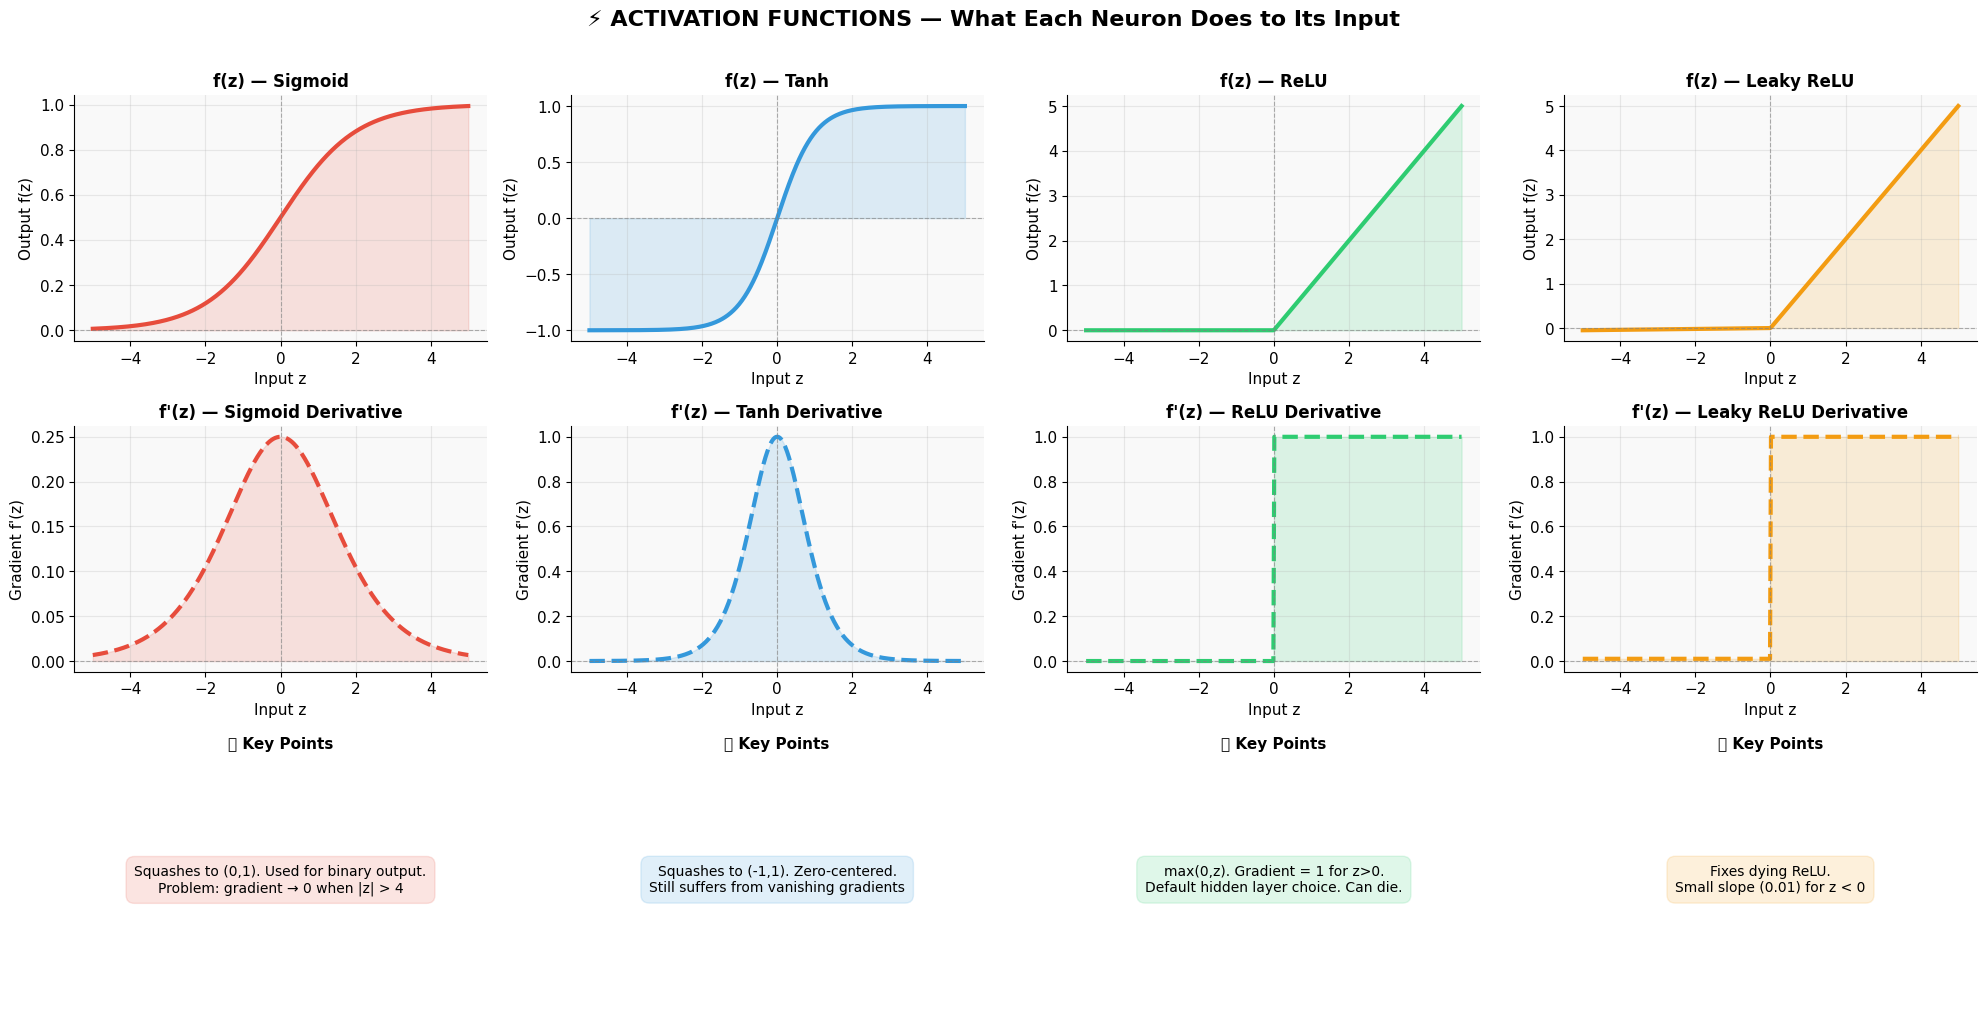

  ✅ Saved → viz1_activations.png

📊 VISUALIZATION 2: Weight Initialization Strategies
--------------------------------------------------


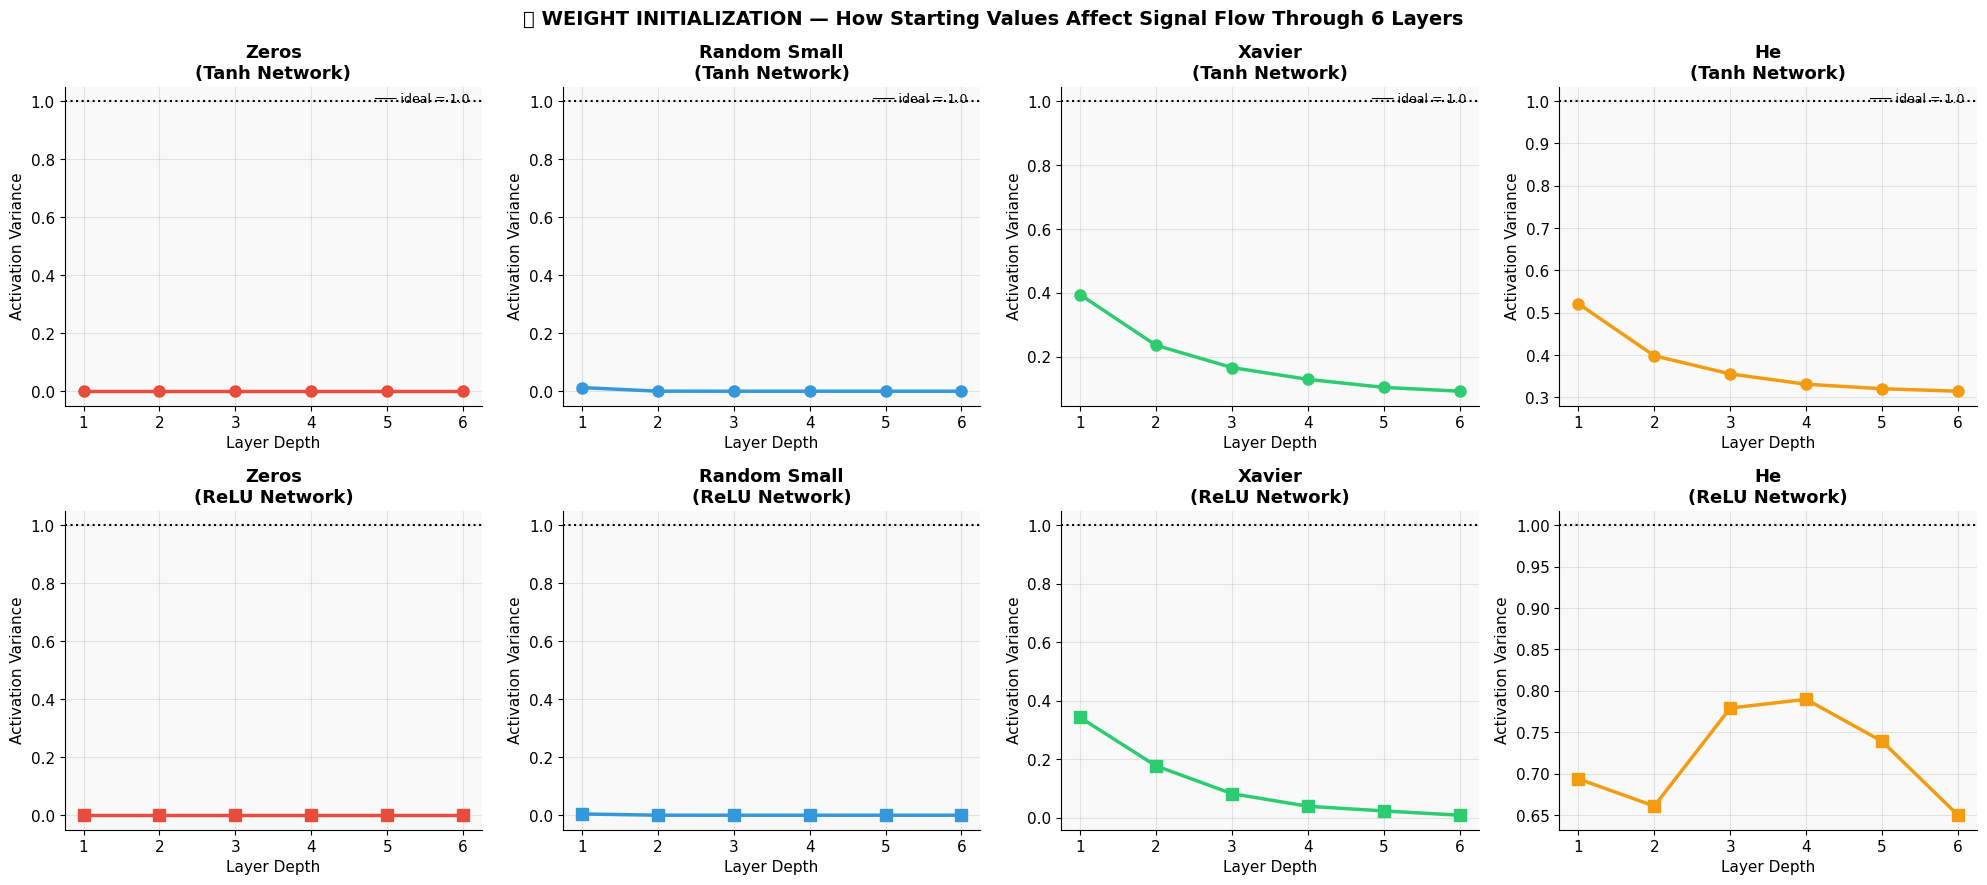

  ✅ Saved → viz2_initialization.png
  📌 Student note: Xavier keeps variance ≈ 1 for Tanh;
     He keeps variance ≈ 1 for ReLU.

  EXPERIMENT A: XOR Problem
  (Simplest non-linearly separable problem)

🔨 Training XOR network...

  NEURAL NETWORK ARCHITECTURE
  Layer 1: Dense(2→8, act='relu')  (Input: 2, Output: 8) [24 params]
  Layer 2: Dense(8→8, act='relu')  (Input: 8, Output: 8) [72 params]
  Layer 3: Dense(8→1, act='sigmoid')  (Input: 8, Output: 1) [9 params]
-------------------------------------------------------
  Total trainable parameters: 105

  Ep   10/200 | loss=0.0087 acc=0.9984 | val_loss=0.0080 val_acc=1.0000
  Ep   20/200 | loss=0.0047 acc=1.0000 | val_loss=0.0039 val_acc=1.0000
  Ep   30/200 | loss=0.0029 acc=0.9984 | val_loss=0.0029 val_acc=1.0000
  Ep   40/200 | loss=0.0029 acc=1.0000 | val_loss=0.0025 val_acc=1.0000
  Ep   50/200 | loss=0.0011 acc=1.0000 | val_loss=0.0021 val_acc=1.0000
  Ep   60/200 | loss=0.0007 acc=1.0000 | val_loss=0.0019 val_acc=1.0000
  Ep   70/

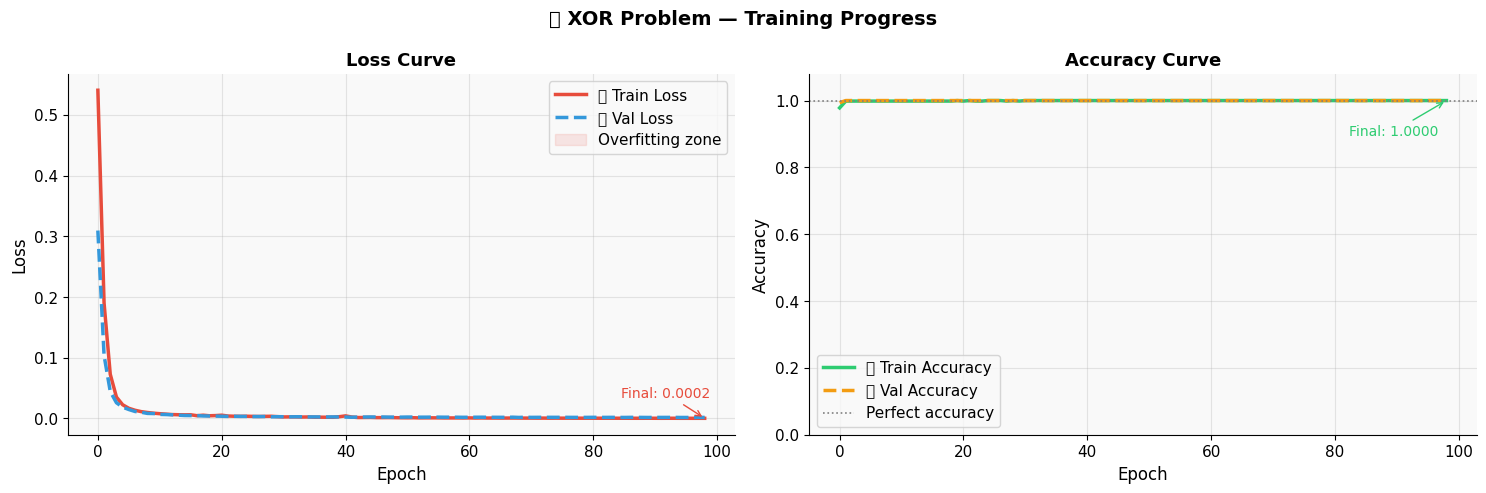

  ✅ Saved → learning_curves_XOR_Problem.png

📊 Decision Boundary: XOR — Learned Boundary


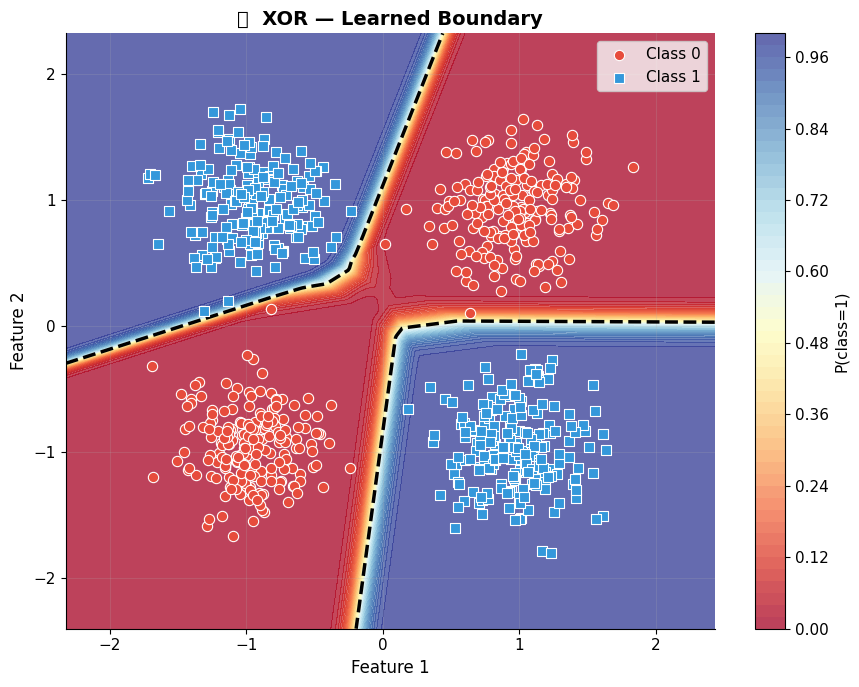

  ✅ Saved → boundary_XOR_—_Learned_Boundary.png

  EXPERIMENT B: Moons Dataset
  (Tests curved non-linear boundaries)

🔨 Training Moons network...

  NEURAL NETWORK ARCHITECTURE
  Layer 1: Dense(2→32, act='relu')  (Input: 2, Output: 32) [96 params]
  Layer 2: BatchNorm(dim=32)
  Layer 3: Dropout(rate=0.2)
  Layer 4: Dense(32→16, act='relu')  (Input: 32, Output: 16) [528 params]
  Layer 5: Dense(16→1, act='sigmoid')  (Input: 16, Output: 1) [17 params]
-------------------------------------------------------
  Total trainable parameters: 641

  Ep   10/200 | loss=0.2272 acc=0.9350 | val_loss=0.2117 val_acc=0.9450
  Ep   20/200 | loss=0.2038 acc=0.9425 | val_loss=0.1782 val_acc=0.9500
  Ep   30/200 | loss=0.2082 acc=0.9425 | val_loss=0.1682 val_acc=0.9600
  Ep   40/200 | loss=0.1926 acc=0.9437 | val_loss=0.1486 val_acc=0.9600
  Ep   50/200 | loss=0.2028 acc=0.9387 | val_loss=0.1533 val_acc=0.9600
  Ep   60/200 | loss=0.1802 acc=0.9437 | val_loss=0.1478 val_acc=0.9650
  Ep   70/200 | loss=0

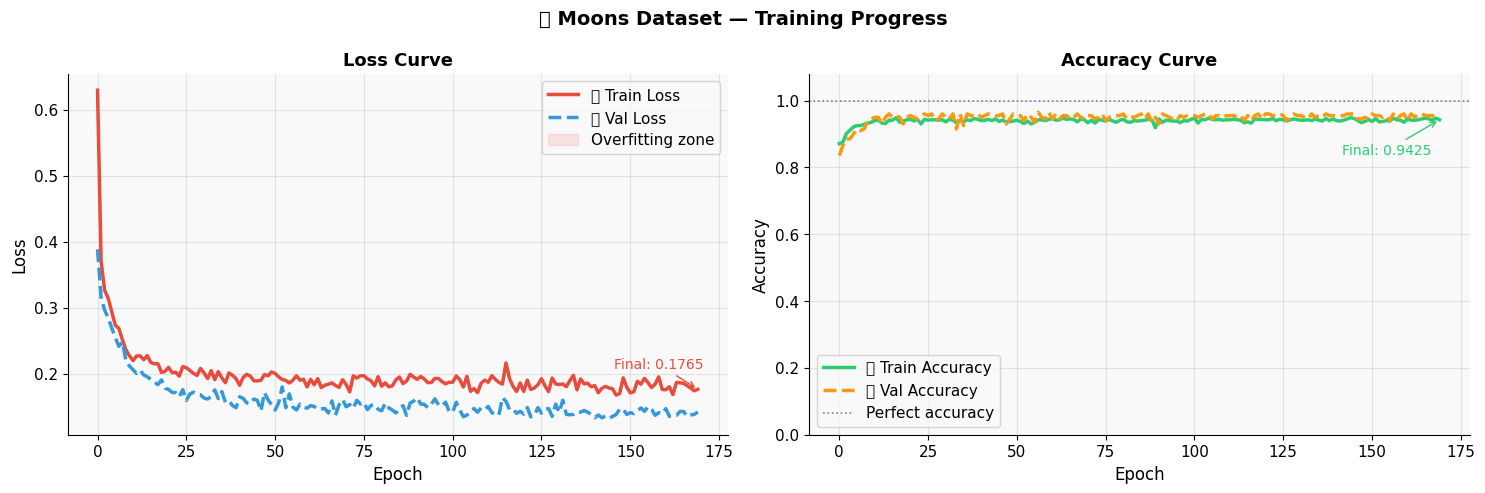

  ✅ Saved → learning_curves_Moons_Dataset.png

📊 Decision Boundary: Moons — Learned Boundary


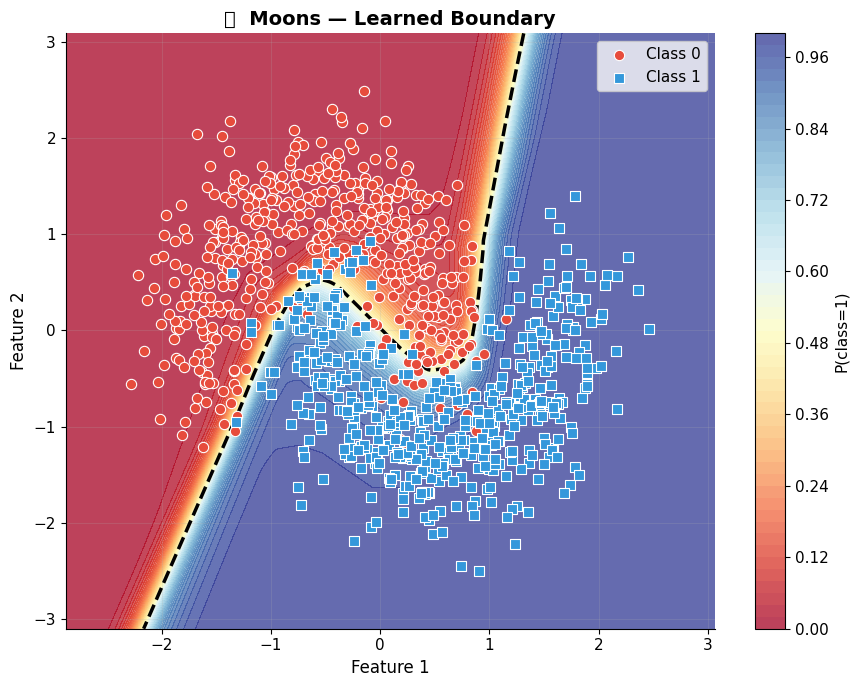

  ✅ Saved → boundary_Moons_—_Learned_Boundary.png

📊 Weight Distributions: Moons Network


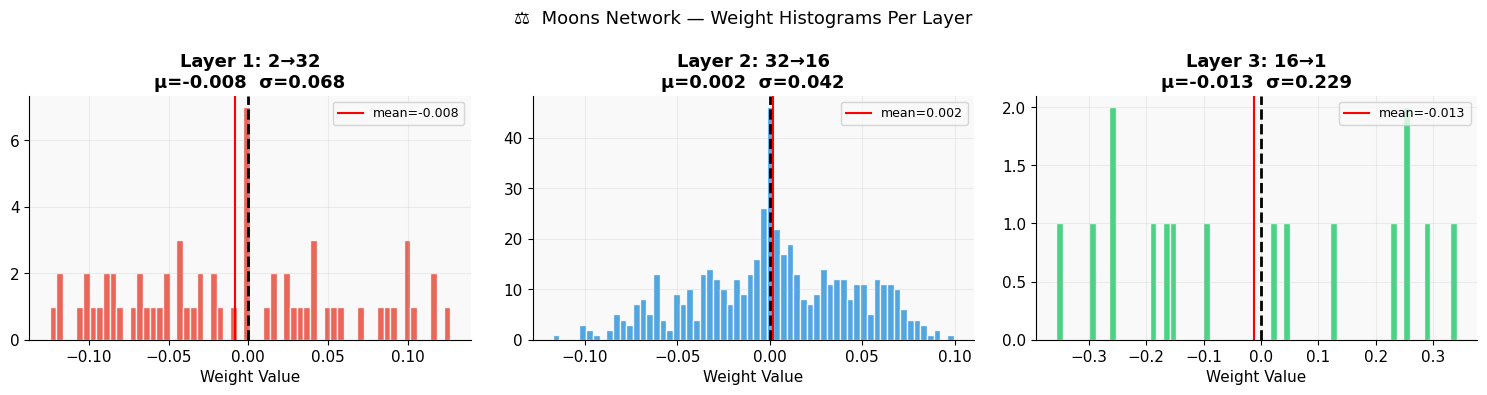

  ✅ Saved → weight_distributions.png

📊 Gradient Flow Analysis


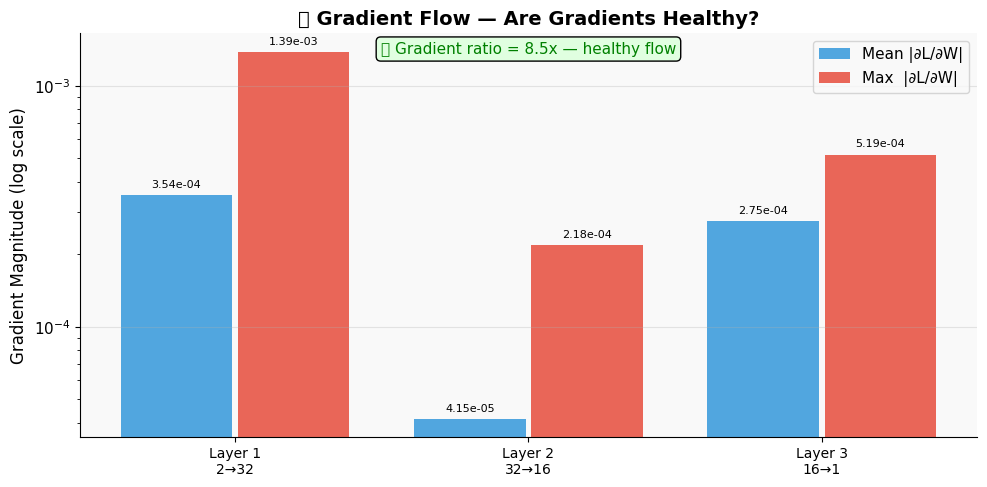

  ✅ Saved → gradient_flow.png

📊 Confusion Matrix: Moons Network


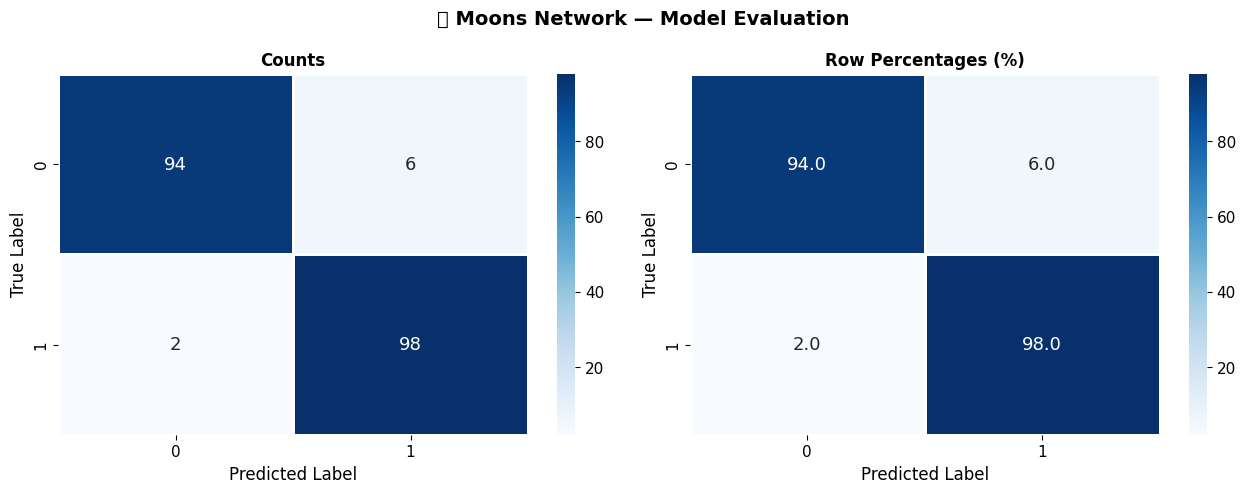


              precision    recall  f1-score   support

           0       0.98      0.94      0.96       100
           1       0.94      0.98      0.96       100

    accuracy                           0.96       200
   macro avg       0.96      0.96      0.96       200
weighted avg       0.96      0.96      0.96       200


📊 Network Architecture Diagram


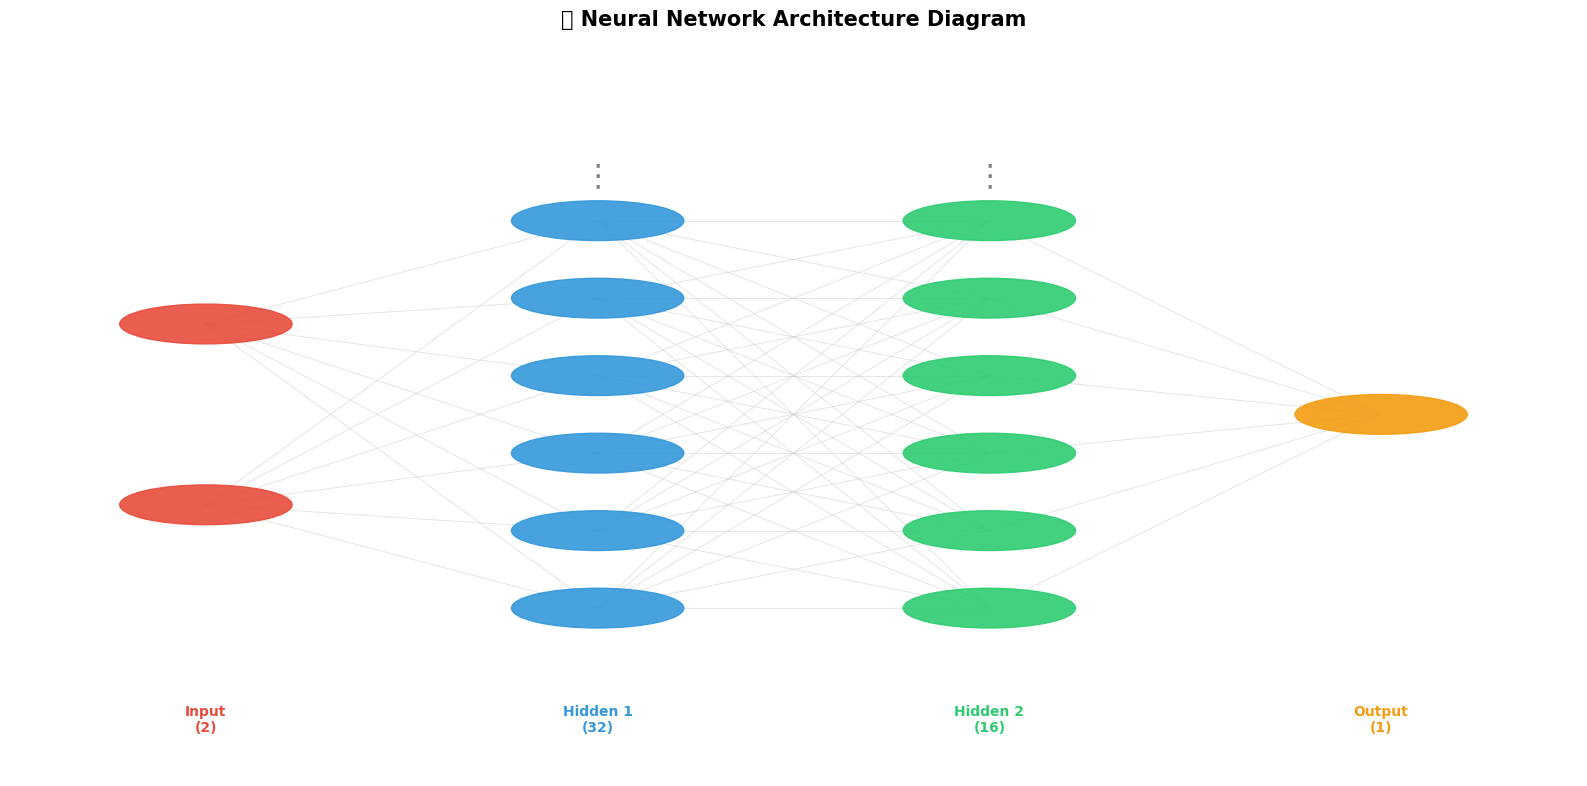

  ✅ Saved → network_diagram.png

  EXPERIMENT C: Multi-class (4 classes)


In [ ]:
# ============================================================
#  BLOCK 9: MAIN RUNNER — EXECUTE EVERYTHING
#  This block trains real networks and shows all visualizations
# ============================================================

def run_complete_lab():
    print("\n")
    print("=" * 60)
    print("  🧠  NEURAL NETWORK TRAINING LAB")
    print("  Complete Student Visualization Run")
    print("=" * 60)

    # ═══════════════════════════════════════════════════════
    #  VIZ 1 — Activation Functions
    # ═══════════════════════════════════════════════════════
    visualize_activations()

    # ═══════════════════════════════════════════════════════
    #  VIZ 2 — Weight Initialization Comparison
    # ═══════════════════════════════════════════════════════
    visualize_initialization()

    # ═══════════════════════════════════════════════════════
    #  EXPERIMENT A — XOR Problem (Classic NN Test)
    # ═══════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("  EXPERIMENT A: XOR Problem")
    print("  (Simplest non-linearly separable problem)")
    print("=" * 60)

    # XOR data: 4 points × 500 noisy copies
    np.random.seed(SEED)
    Xor_X = np.array([[0,0],[0,1],[1,0],[1,1]] * 200,
                      dtype=float)
    Xor_X += np.random.randn(*Xor_X.shape) * 0.15
    Xor_y = np.array([0,1,1,0] * 200, dtype=float).reshape(-1, 1)

    scaler_xor = StandardScaler()
    Xor_X      = scaler_xor.fit_transform(Xor_X)

    X_tr, X_v, y_tr, y_v = train_test_split(
        Xor_X, Xor_y, test_size=0.2, random_state=SEED)

    xor_configs = [
        {'type':'dense', 'input_dim':2, 'units':8,
         'activation':'relu'},
        {'type':'dense', 'input_dim':8, 'units':8,
         'activation':'relu'},
        {'type':'dense', 'input_dim':8, 'units':1,
         'activation':'sigmoid'},
    ]

    print("\n🔨 Training XOR network...")
    xor_model = NeuralNetwork(xor_configs,
                              loss='binary_crossentropy',
                              optimizer='adam',
                              learning_rate=0.01)
    xor_model.summary()
    xor_model.train(X_tr, y_tr, epochs=200, batch_size=32,
                    X_val=X_v, y_val=y_v,
                    early_stopping_patience=30,
                    verbose=True)

    plot_learning_curves(xor_model.history,
                         title="XOR Problem")
    plot_decision_boundary(xor_model, Xor_X, Xor_y,
                           title="XOR — Learned Boundary")

    # ═══════════════════════════════════════════════════════
    #  EXPERIMENT B — Moons Dataset (Curved Boundary)
    # ═══════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("  EXPERIMENT B: Moons Dataset")
    print("  (Tests curved non-linear boundaries)")
    print("=" * 60)

    X_m, y_m = make_moons(n_samples=1000, noise=0.25,
                           random_state=SEED)
    scaler_m  = StandardScaler()
    X_m       = scaler_m.fit_transform(X_m)
    y_m       = y_m.reshape(-1, 1).astype(float)

    X_mtr, X_mv, y_mtr, y_mv = train_test_split(
        X_m, y_m, test_size=0.2, random_state=SEED)

    moon_configs = [
        {'type':'dense',    'input_dim':2,  'units':32,
         'activation':'relu'},
        {'type':'batchnorm','dim':32},
        {'type':'dropout',  'rate':0.2},
        {'type':'dense',    'input_dim':32, 'units':16,
         'activation':'relu'},
        {'type':'dense',    'input_dim':16, 'units':1,
         'activation':'sigmoid'},
    ]

    print("\n🔨 Training Moons network...")
    moon_model = NeuralNetwork(moon_configs,
                               loss='binary_crossentropy',
                               optimizer='adam',
                               learning_rate=0.005,
                               l2_lambda=0.001)
    moon_model.summary()
    moon_model.train(X_mtr, y_mtr, epochs=200, batch_size=64,
                     X_val=X_mv, y_val=y_mv,
                     early_stopping_patience=25,
                     verbose=True)

    plot_learning_curves(moon_model.history,
                         title="Moons Dataset")
    plot_decision_boundary(moon_model, X_m, y_m,
                           title="Moons — Learned Boundary")

    # ── Weight & gradient diagnostics ──────────────────────
    plot_weight_distributions(moon_model,
                              title="Moons Network")
    plot_gradient_flow(moon_model,
                       X_mtr[:128], y_mtr[:128])

    # ── Confusion matrix ────────────────────────────────────
    y_pred_m = moon_model.predict_classes(X_mv)
    plot_confusion_matrix_report(
        y_mv.flatten().astype(int), y_pred_m,
        title="Moons Network")

    # ── Network diagram ────────────────────────────────────
    plot_network_diagram([2, 32, 16, 1])

    # ═══════════════════════════════════════════════════════
    #  EXPERIMENT C — Multi-class Classification
    # ═══════════════════════════════════════════════════════
    print("\n" + "=" * 60)
    print("  EXPERIMENT C: Multi-class (4 classes)")
    print("=" * 60)

    X_mc, y_mc = make_classification(
        n_samples=1200, n_features=2,
        n_informative=2, n_redundant=0)
    scaler_mc = StandardScaler()
    X_mc      = scaler_mc.fit_transform(X_mc)
    y_mc      = y_mc.reshape(-1, 1)


    X_mctr, X_mcv, y_mctr, y_mcv = train_test_split(
        X_mc, y_mc, test_size=0.2, random_state=SEED)


 # ============================================================
#  ENTRY POINT
# ============================================================
if __name__ == "__main__":
    run_complete_lab()

TEST YOUR KNOWLEDGE

# Ensure you execute this first

In [2]:
%%capture
pip install fpdf2 PyGithub


# **instructions**
generate your git hub token using the steps below and paste it on the line one under github configurations

# steps in generation your PAT

Step 1: Generate the GitHub Personal Access Token (PAT)Log into your GitHub Account .
Click your Profile Icon in the top-right corner and select Settings .Scroll down on the left sidebar and click Developer settings .

Expand Personal access tokens and select Tokens (classic) .

Click Generate new token (choose Generate new token (classic) if prompted).
Give your token a descriptive name in the Note field (eg, "Colab Push Token").
Check the box for repo(this allows you to pull and push to your repositories) chose first choice .

Scroll to the bottom and click Generate token .

 Copy the token immediately. You will not be able to see it again



# Once you have done this attempt all questions , dont change any part of this code

In [11]:
# ============================================================
#  DeKUT — NEURAL NETWORK LAB ASSESSMENT
#  Save as : assessment.py
#  Run     : python assessment.py
#  Install : pip install fpdf2 PyGithub
#  Test    : python assessment.py demo
#  Results : python assessment.py results
# ============================================================

import textwrap, csv, os, sys, time, warnings, hashlib, subprocess
from datetime import datetime

warnings.filterwarnings("ignore")

# ── Auto-install dependencies if missing ─────────────────────
def _ensure(package, import_name=None):
    import importlib
    import_name = import_name or package
    try:
        importlib.import_module(import_name)
    except ImportError:
        print(f"  Installing {package}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package, "--quiet"])

_ensure("fpdf2",     "fpdf")
_ensure("PyGithub",  "github")

try:
    from fpdf import FPDF
    PDF_AVAILABLE = True
except ImportError:
    PDF_AVAILABLE = False
    print("  [WARN] fpdf2 could not be loaded. PDF will be skipped.")

try:
    from github import Github, GithubException
    PYGITHUB_AVAILABLE = True
except ImportError:
    PYGITHUB_AVAILABLE = False
    print("  [WARN] PyGithub could not be loaded. GitHub push will be skipped.")

# ============================================================
#  CONFIGURATION  <- Edit these two values
# ============================================================

GITHUB_TOKEN          = "your github token here" # <- paste PAT here
GITHUB_REPO           = "sirrom/4th-year-assignments-"  # <- owner/repo
GITHUB_BRANCH         = "main"
GITHUB_RESULTS_FOLDER = "lab_results"
RESULTS_CSV           = "lab_assessment_results.csv"

# ============================================================
#  ANSWER HASHING
#  Correct letters are stored as SHA-256 hashes with a salt.
#  No one reading the source code can see the answer letters.
# ============================================================

_SALT = "DeKUT_NNLab_2024_xQ7#"

def _hash(letter):
    return hashlib.sha256((_SALT + letter).encode()).hexdigest()

def _check(student_answer, stored_hash):
    return hashlib.sha256((_SALT + student_answer).encode()).hexdigest() == stored_hash

def _reveal(stored_hash):
    """Recover the plain letter from a hash (instructor use only)."""
    for L in ("A", "B", "C", "D"):
        if _check(L, stored_hash):
            return L
    return "?"

HA, HB, HC, HD = _hash("A"), _hash("B"), _hash("C"), _hash("D")

# ============================================================
#  HELPERS
# ============================================================

def pdf_safe(text):
    """Strip characters outside latin-1 so Helvetica never crashes."""
    return str(text).encode("latin-1", errors="ignore").decode("latin-1")

def safe_filename(reg_no):
    """Turn E023-01-0001/2023 into E023-01-0001_2023 for filenames."""
    return reg_no.replace("/", "_").replace(" ", "_").replace("\\", "_")

# ============================================================
#  QUESTION BANK — 28 questions, 8 sections
#  "answer" field holds a SHA-256 hash, never a plain letter
# ============================================================

QUESTIONS = []

# ── Section 1: Activation Functions (5) ──────────────────────
QUESTIONS.append({
    "id": 1, "section": "Activation Functions",
    "q": "What is the output range of the Sigmoid activation function?",
    "options": ["A) (-inf, +inf)", "B) (-1, 1)", "C) (0, 1)", "D) (0, +inf)"],
    "answer": HC,
    "explain": (
        "Sigmoid = 1/(1+e^-z). As z->+inf output->1, as z->-inf output->0. "
        "It never reaches 0 or 1, so the range is the open interval (0, 1)."
    ),
})
QUESTIONS.append({
    "id": 2, "section": "Activation Functions",
    "q": "Which activation function suffers from the 'Dying ReLU' problem?",
    "options": ["A) Sigmoid", "B) Tanh", "C) ReLU", "D) Softmax"],
    "answer": HC,
    "explain": (
        "ReLU outputs 0 for all z<=0 and its gradient is also 0 there. "
        "A neuron stuck at 0 stops receiving gradient updates and dies. "
        "Leaky ReLU fixes this with a small slope (0.01) for negative inputs."
    ),
})
QUESTIONS.append({
    "id": 3, "section": "Activation Functions",
    "q": "Why is Tanh preferred over Sigmoid for hidden layers?",
    "options": [
        "A) Tanh is faster to compute",
        "B) Tanh outputs are zero-centered, making gradient updates more balanced",
        "C) Tanh has no vanishing gradient problem",
        "D) Tanh range is (0,1) which is easier to interpret",
    ],
    "answer": HB,
    "explain": (
        "Tanh outputs range (-1, 1) centered around 0. "
        "Sigmoid outputs (0, 1) are always positive, causing zig-zag gradient updates. "
        "Zero-centering avoids this inefficiency."
    ),
})
QUESTIONS.append({
    "id": 4, "section": "Activation Functions",
    "q": "What does the derivative of ReLU equal for z = 3.5?",
    "options": ["A) 0", "B) 3.5", "C) 1", "D) 0.5"],
    "answer": HC,
    "explain": (
        "ReLU derivative = 1 if z > 0, else 0. "
        "Since z=3.5 > 0, the derivative is exactly 1."
    ),
})
QUESTIONS.append({
    "id": 5, "section": "Activation Functions",
    "q": "Which activation function should you use in the OUTPUT layer for a multi-class classification problem with 4 classes?",
    "options": ["A) ReLU", "B) Sigmoid", "C) Tanh", "D) Softmax"],
    "answer": HD,
    "explain": (
        "Softmax converts raw scores into a probability distribution summing to 1. "
        "Each output = P(class=k). Use Sigmoid only for binary (2-class) output."
    ),
})

# ── Section 2: Weight Initialization (3) ─────────────────────
QUESTIONS.append({
    "id": 6, "section": "Weight Initialization",
    "q": "What problem occurs if you initialize ALL weights to zero?",
    "options": [
        "A) The network trains too fast",
        "B) All neurons learn identical features - symmetry problem",
        "C) Gradients become too large",
        "D) The loss function becomes undefined",
    ],
    "answer": HB,
    "explain": (
        "With all weights=0, every neuron computes the same output and gets "
        "the same gradient. They update identically forever and symmetry is never broken."
    ),
})
QUESTIONS.append({
    "id": 7, "section": "Weight Initialization",
    "q": "Which initializer is recommended when using ReLU activations?",
    "options": ["A) Zeros", "B) Xavier (Glorot)", "C) He (Kaiming)", "D) Random Large"],
    "answer": HC,
    "explain": (
        "He initialization: std = sqrt(2/fan_in). "
        "The factor 2 compensates for ReLU zeroing roughly half the neurons. "
        "Xavier uses sqrt(2/(fan_in+fan_out)), designed for Tanh/Sigmoid."
    ),
})
QUESTIONS.append({
    "id": 8, "section": "Weight Initialization",
    "q": "What does 'fan_in' mean in the context of weight initialization?",
    "options": [
        "A) The number of output neurons in the current layer",
        "B) The number of input neurons feeding into the current layer",
        "C) The total number of parameters in the network",
        "D) The learning rate scaling factor",
    ],
    "answer": HB,
    "explain": (
        "fan_in = number of inputs to a layer (input dimension). "
        "fan_out = number of outputs. Xavier uses both; He uses only fan_in."
    ),
})

# ── Section 3: Loss Functions (3) ────────────────────────────
QUESTIONS.append({
    "id": 9, "section": "Loss Functions",
    "q": "Which loss function should you use for BINARY classification?",
    "options": [
        "A) Mean Squared Error",
        "B) Categorical Cross-Entropy",
        "C) Binary Cross-Entropy",
        "D) Hinge Loss",
    ],
    "answer": HC,
    "explain": (
        "Binary Cross-Entropy = -[y*log(p) + (1-y)*log(1-p)]. "
        "Designed for 2-class problems with a Sigmoid output."
    ),
})
QUESTIONS.append({
    "id": 10, "section": "Loss Functions",
    "q": "A model predicts p=0.95 for a sample with true label y=1. What is the Binary Cross-Entropy loss?",
    "options": ["A) 0.95", "B) ~0.051", "C) ~0.5", "D) 0.0"],
    "answer": HB,
    "explain": (
        "BCE = -log(0.95) = ~0.051. A confident correct prediction gives a very small loss. "
        "If p=0.05 for y=1, loss = -log(0.05) = ~3.0."
    ),
})
QUESTIONS.append({
    "id": 11, "section": "Loss Functions",
    "q": "Why do we clip predictions before computing cross-entropy loss (e.g. clip to 1e-12, 1-1e-12)?",
    "options": [
        "A) To speed up computation",
        "B) To prevent log(0) which is negative infinity",
        "C) To normalize predictions to sum to 1",
        "D) To apply L2 regularization",
    ],
    "answer": HB,
    "explain": (
        "log(0) = -inf, making the loss undefined (NaN). "
        "Clipping keeps log() finite and numerically stable."
    ),
})

# ── Section 4: Optimizers (4) ────────────────────────────────
QUESTIONS.append({
    "id": 12, "section": "Optimizers",
    "q": "What does the momentum term do in SGD with Momentum?",
    "options": [
        "A) Increases the learning rate over time",
        "B) Accumulates a velocity in the gradient direction to accelerate convergence",
        "C) Randomly skips gradient updates",
        "D) Normalizes the gradient to unit length",
    ],
    "answer": HB,
    "explain": (
        "Momentum: v = beta*v + lr*grad. "
        "Accelerates movement in consistent directions and dampens oscillations. "
        "Typical beta=0.9 retains 90% of previous velocity."
    ),
})
QUESTIONS.append({
    "id": 13, "section": "Optimizers",
    "q": "Adam optimizer combines which two techniques?",
    "options": [
        "A) SGD + Dropout",
        "B) Momentum + RMSProp (adaptive learning rates)",
        "C) L1 + L2 Regularization",
        "D) Batch Normalization + Weight Decay",
    ],
    "answer": HB,
    "explain": (
        "Adam maintains m (first moment, like momentum) and "
        "v (second moment, like RMSProp). "
        "Update: theta -= lr * m_hat / (sqrt(v_hat) + eps)."
    ),
})
QUESTIONS.append({
    "id": 14, "section": "Optimizers",
    "q": "Which optimizer typically converges fastest on small datasets?",
    "options": [
        "A) Vanilla SGD (no momentum)",
        "B) SGD with Momentum",
        "C) Adam",
        "D) They all converge at exactly the same speed",
    ],
    "answer": HC,
    "explain": (
        "Adam adapts the learning rate per-parameter using gradient history, "
        "making it robust to different gradient scales."
    ),
})
QUESTIONS.append({
    "id": 15, "section": "Optimizers",
    "q": "What is the purpose of bias correction in Adam (dividing by 1 - beta^t)?",
    "options": [
        "A) To prevent the learning rate from growing too large",
        "B) To correct for m and v being initialized at zero, biased toward zero in early steps",
        "C) To apply L2 regularization to the weights",
        "D) To normalize the batch size effect",
    ],
    "answer": HB,
    "explain": (
        "At t=1, m is tiny because it started at 0. "
        "Dividing by (1-beta^t) scales it back to the true gradient magnitude."
    ),
})

# ── Section 5: Backpropagation (3) ───────────────────────────
QUESTIONS.append({
    "id": 16, "section": "Backpropagation",
    "q": "What does the chain rule tell us in backpropagation?",
    "options": [
        "A) How to initialize weights before training",
        "B) How to compute the gradient of the loss w.r.t each weight by multiplying local gradients layer by layer",
        "C) How to choose the optimal learning rate",
        "D) How to split data into mini-batches",
    ],
    "answer": HB,
    "explain": (
        "Chain rule: dL/dW1 = (dL/da2)*(da2/dz2)*(dz2/da1)*(da1/dz1)*(dz1/dW1). "
        "Each term is a local gradient multiplied going backward."
    ),
})
QUESTIONS.append({
    "id": 17, "section": "Backpropagation",
    "q": "What is the vanishing gradient problem?",
    "options": [
        "A) Gradients become extremely large and cause weight overflow",
        "B) Gradients shrink exponentially backward through many layers, making early layers learn very slowly",
        "C) The loss function gradient becomes undefined",
        "D) Dropout removes too many gradients during backprop",
    ],
    "answer": HB,
    "explain": (
        "Sigmoid derivative max = 0.25. In a 10-layer net, "
        "gradient shrinks to 0.25^10 = ~0.000001 at layer 1. "
        "ReLU derivative = 1 for z>0, so gradients do not shrink."
    ),
})
QUESTIONS.append({
    "id": 18, "section": "Backpropagation",
    "q": "In a gradient flow chart, what does a gradient ratio greater than 1000x between layers indicate?",
    "options": [
        "A) The network is training perfectly",
        "B) Some layers have near-zero gradients - vanishing or exploding gradient problem",
        "C) The learning rate is too small",
        "D) The batch size needs to be increased",
    ],
    "answer": HB,
    "explain": (
        "1000x difference means early layers receive almost no learning signal. "
        "Fix: use ReLU, BatchNorm, or residual connections."
    ),
})

# ── Section 6: Regularization (4) ────────────────────────────
QUESTIONS.append({
    "id": 19, "section": "Regularization",
    "q": "What is overfitting?",
    "options": [
        "A) The model performs well on both train and test data",
        "B) The model memorizes training data and performs poorly on unseen data",
        "C) The model is too simple to capture patterns in the data",
        "D) The learning rate is too high",
    ],
    "answer": HB,
    "explain": (
        "Overfitting = low train loss but high val loss. "
        "The model memorizes noise instead of learning general patterns."
    ),
})
QUESTIONS.append({
    "id": 20, "section": "Regularization",
    "q": "How does Dropout prevent overfitting?",
    "options": [
        "A) It reduces the learning rate each epoch",
        "B) It randomly deactivates neurons during training, preventing co-adaptation",
        "C) It adds a penalty term to the loss function",
        "D) It clips gradient values above a threshold",
    ],
    "answer": HB,
    "explain": (
        "With dropout rate=0.5, each neuron is randomly off 50% of training time. "
        "This prevents co-adaptation. At inference time, dropout is OFF."
    ),
})
QUESTIONS.append({
    "id": 21, "section": "Regularization",
    "q": "L2 regularization adds lambda multiplied by the sum of squared weights to the loss. What effect does this have?",
    "options": [
        "A) It pushes weights toward exactly zero (sparse weights)",
        "B) It pushes weights toward small values but not exactly zero",
        "C) It increases all weights proportionally",
        "D) It has no effect on weights, only on biases",
    ],
    "answer": HB,
    "explain": (
        "L2 adds lambda*W to each gradient update, decaying weights toward 0 "
        "but never exactly 0. Also called weight decay."
    ),
})
QUESTIONS.append({
    "id": 22, "section": "Regularization",
    "q": "Which regularization setup produces the SMALLEST train/val loss gap?",
    "options": [
        "A) No Regularization",
        "B) L2 Only",
        "C) Dropout Only",
        "D) L2 + Dropout combined",
    ],
    "answer": HD,
    "explain": (
        "L2 + Dropout combines weight penalty and random deactivation, "
        "providing stronger regularization than either alone."
    ),
})

# ── Section 7: Batch Normalization (2) ───────────────────────
QUESTIONS.append({
    "id": 23, "section": "Batch Normalization",
    "q": "What does Batch Normalization do to its input?",
    "options": [
        "A) Randomly sets 50% of inputs to zero",
        "B) Normalizes inputs to mean=0 and std=1, then scales with learned gamma and shifts with learned beta",
        "C) Clips all inputs to the range (-1, 1)",
        "D) Multiplies inputs by a fixed constant",
    ],
    "answer": HB,
    "explain": (
        "BN: x_norm = (x - mu) / sqrt(var + eps), output = gamma*x_norm + beta. "
        "gamma and beta are learned. Reduces internal covariate shift."
    ),
})
QUESTIONS.append({
    "id": 24, "section": "Batch Normalization",
    "q": "Why does BatchNorm behave differently during training versus inference?",
    "options": [
        "A) It uses different activation functions at test time",
        "B) Training uses batch statistics; inference uses running averages accumulated during training",
        "C) It applies dropout only during inference",
        "D) It freezes all weights during inference",
    ],
    "answer": HB,
    "explain": (
        "Training: mu and var from current mini-batch. "
        "Inference: uses stable running_mean and running_var (EMA). "
        "Needed because test batch size may be just 1."
    ),
})

# ── Section 8: Architecture Design (4) ───────────────────────
QUESTIONS.append({
    "id": 25, "section": "Architecture Design",
    "q": "Why does the output layer use Sigmoid and NOT ReLU for binary classification?",
    "options": [
        "A) ReLU is too slow for output layers",
        "B) The output must be a probability in (0,1) - Sigmoid provides this, ReLU does not",
        "C) ReLU cannot handle 1-dimensional output",
        "D) Sigmoid has a higher gradient at the output",
    ],
    "answer": HB,
    "explain": (
        "Binary cross-entropy expects predictions in (0,1). "
        "Sigmoid squashes any real number to (0,1). "
        "ReLU could output 5.3 which has no probabilistic meaning."
    ),
})
QUESTIONS.append({
    "id": 26, "section": "Architecture Design",
    "q": "What is the purpose of using mini-batches during training with batch size 32?",
    "options": [
        "A) To evaluate the model on validation data",
        "B) To compute an approximate gradient over a subset - faster than full dataset, less noisy than single samples",
        "C) To apply dropout to exactly 32 neurons",
        "D) To split data into train and test sets",
    ],
    "answer": HB,
    "explain": (
        "Full-batch GD: exact gradient but slow. SGD (batch=1): fast but noisy. "
        "Mini-batch (32-256): balances speed and gradient quality."
    ),
})
QUESTIONS.append({
    "id": 27, "section": "Architecture Design",
    "q": "Early stopping uses patience=30. What does this mean?",
    "options": [
        "A) Training stops after exactly 30 epochs",
        "B) Training stops if val loss does not improve for 30 consecutive epochs, restoring best weights",
        "C) The learning rate is reduced every 30 epochs",
        "D) Dropout rate increases by 30% after convergence",
    ],
    "answer": HB,
    "explain": (
        "No improvement for 30 consecutive epochs triggers a stop "
        "and restores the weights from the best epoch seen."
    ),
})
QUESTIONS.append({
    "id": 28, "section": "Architecture Design",
    "q": "Why can a single layer with no hidden layers NOT solve the XOR problem?",
    "options": [
        "A) Single layers cannot handle 2D input",
        "B) XOR is not linearly separable - no straight line can divide the two classes",
        "C) Single layers have too many parameters",
        "D) XOR requires Softmax which needs multiple layers",
    ],
    "answer": HB,
    "explain": (
        "XOR: (0,0)->0, (0,1)->1, (1,0)->1, (1,1)->0. "
        "No straight line separates the 0s from the 1s. "
        "A hidden layer creates a non-linear transformation making classes separable."
    ),
})

assert len(QUESTIONS) == 28, f"Expected 28 questions, got {len(QUESTIONS)}"

# ============================================================
#  STUDENT REGISTRATION
# ============================================================

def capture_student_info():
    print("\n" + "=" * 62)
    print("   DEDAN KIMATHI UNIVERSITY OF TECHNOLOGY")
    print("   Neural Network Lab - Student Assessment")
    print("   28 Questions  |  8 Topics  |  Multiple Choice")
    print("=" * 62 + "\n")

    while True:
        reg_no = input("  Enter Registration Number (e.g. E023-01-0001/2023): ").strip().upper()
        if len(reg_no) >= 5:
            break
        print("  Too short. Try again.\n")

    while True:
        full_name = input("  Enter Full Name (Surname First)              : ").strip().title()
        if len(full_name.split()) >= 2:
            break
        print("  Enter at least first and last name.\n")

    print()
    print("  +---------------------------------------------------------+")
    print(f"  | Reg No   : {reg_no:<47}|")
    print(f"  | Name     : {full_name:<47}|")
    print(f"  | Date     : {datetime.now().strftime('%Y-%m-%d %H:%M'):<47}|")
    print("  +---------------------------------------------------------+")
    print()

    confirm = input("  Confirm details are correct? (Y/N): ").strip().upper()
    if confirm != "Y":
        print("\n  Re-entering details...\n")
        return capture_student_info()

    print("\n  [OK] Details confirmed. Starting in 3 seconds...\n")
    for i in [3, 2, 1]:
        print(f"       {i}...")
        time.sleep(1)
    print()

    fname = safe_filename(reg_no)
    return {
        "reg_no"    : reg_no,
        "full_name" : full_name,
        "timestamp" : datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "date"      : datetime.now().strftime("%Y-%m-%d"),
        "safe_reg"  : fname,
        "csv_file"  : f"result_{fname}.csv",
        "pdf_file"  : f"result_{fname}.pdf",
    }

# ============================================================
#  CSV STORE
# ============================================================

def build_csv_row(student, score, total, sections, pct, grade, wrong_ids):
    row = {
        "timestamp"      : student["timestamp"],
        "reg_no"         : student["reg_no"],
        "full_name"      : student["full_name"],
        "score"          : score,
        "total"          : total,
        "percentage"     : f"{pct:.1f}",
        "grade"          : grade,
        "wrong_questions": wrong_ids,
    }
    for sec, res in sections.items():
        row[sec] = f"{res['correct']}/{res['total']}"
    return row


def save_to_csv(student, score, total, sections, wrong):
    pct      = score / total * 100
    grade    = "A" if pct>=90 else "B" if pct>=75 else "C" if pct>=60 else "D" if pct>=50 else "F"
    wrong_ids = "|".join([f"Q{q['id']}" for q in wrong]) if wrong else "None"

    fieldnames = [
        "timestamp","reg_no","full_name","score","total","percentage","grade",
        "wrong_questions","Activation Functions","Weight Initialization",
        "Loss Functions","Optimizers","Backpropagation","Regularization",
        "Batch Normalization","Architecture Design",
    ]

    # Per-student file
    with open(student["csv_file"], "w", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerow(build_csv_row(student, score, total, sections, pct, grade, wrong_ids))
    print(f"  [OK] Student CSV  -> {student['csv_file']}")

    # Master file (append)
    master_exists = os.path.isfile(RESULTS_CSV)
    with open(RESULTS_CSV, "a", newline="", encoding="utf-8") as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        if not master_exists:
            w.writeheader()
        w.writerow(build_csv_row(student, score, total, sections, pct, grade, wrong_ids))
    print(f"  [OK] Master CSV   -> {RESULTS_CSV}")

# ============================================================
#  PDF REPORT
# ============================================================

def generate_pdf(student, score, total, sections, wrong):
    if not PDF_AVAILABLE:
        print("  [SKIP] PDF not generated - fpdf2 unavailable.")
        return None

    pct      = score / total * 100
    grade    = "A" if pct>=90 else "B" if pct>=75 else "C" if pct>=60 else "D" if pct>=50 else "F"
    filename = student["pdf_file"]

    pdf = FPDF()
    pdf.add_page()

    # Header bar
    pdf.set_fill_color(26, 60, 120)
    pdf.rect(0, 0, 210, 38, "F")
    pdf.set_text_color(255, 255, 255)
    pdf.set_font("Helvetica", "B", 16)
    pdf.set_xy(10, 7)
    pdf.cell(0, 8, pdf_safe("DEDAN KIMATHI UNIVERSITY OF TECHNOLOGY"), ln=True)
    pdf.set_font("Helvetica", "", 11)
    pdf.set_xy(10, 18)
    pdf.cell(0, 6, pdf_safe("Neural Network Lab - Assessment Report"), ln=True)
    pdf.set_font("Helvetica", "I", 9)
    pdf.set_xy(10, 28)
    pdf.cell(0, 5, pdf_safe(f"Generated: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}"), ln=True)
    pdf.set_text_color(0, 0, 0)
    pdf.ln(14)

    # Student info table
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, pdf_safe("Student Information"), ln=True)
    pdf.set_font("Helvetica", "", 10)
    for label, value in [("Full Name",  student["full_name"]),
                          ("Reg No",    student["reg_no"]),
                          ("Submitted", student["timestamp"])]:
        pdf.set_fill_color(237, 242, 255)
        pdf.cell(48, 7, pdf_safe(f"  {label}"), border=1, fill=True)
        pdf.cell(0,  7, pdf_safe(f"  {value}"), border=1, ln=True)
    pdf.ln(6)

    # Score banner
    sc = (0, 160, 0) if pct >= 75 else (200, 130, 0) if pct >= 60 else (200, 0, 0)
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, pdf_safe("Overall Result"), ln=True)
    pdf.set_font("Helvetica", "B", 28)
    pdf.set_text_color(*sc)
    pdf.cell(0, 12, pdf_safe(f"  {score}/{total}   ({pct:.1f}%)   Grade: {grade}"), ln=True)
    pdf.set_text_color(0, 0, 0)
    pdf.ln(4)

    # Section breakdown table
    pdf.set_font("Helvetica", "B", 12)
    pdf.cell(0, 8, pdf_safe("Score by Section"), ln=True)
    pdf.set_font("Helvetica", "B", 10)
    pdf.set_fill_color(26, 60, 120)
    pdf.set_text_color(255, 255, 255)
    pdf.cell(95, 7, pdf_safe("  Section"), border=1, fill=True)
    pdf.cell(30, 7, pdf_safe("  Score"),   border=1, fill=True)
    pdf.cell(35, 7, pdf_safe("  Pct"),     border=1, fill=True, ln=True)
    pdf.set_text_color(0, 0, 0)
    pdf.set_font("Helvetica", "", 10)
    for idx, (sec, res) in enumerate(sections.items()):
        sp   = res["correct"] / res["total"] * 100
        fill = idx % 2 == 0
        pdf.set_fill_color(245, 248, 255) if fill else pdf.set_fill_color(255, 255, 255)
        pdf.cell(95, 6, pdf_safe(f"  {sec}"),                           border=1, fill=fill)
        pdf.cell(30, 6, pdf_safe(f"  {res['correct']}/{res['total']}"), border=1, fill=fill)
        pdf.cell(35, 6, pdf_safe(f"  {sp:.1f}%"),                      border=1, fill=fill, ln=True)
    pdf.ln(6)

    # Wrong questions section
    pdf.set_font("Helvetica", "B", 12)
    if wrong:
        pdf.cell(0, 8, pdf_safe("Questions to Review"), ln=True)
        for q in wrong:
            pdf.set_font("Helvetica", "B", 10)
            pdf.set_fill_color(255, 230, 230)
            pdf.cell(0, 6,
                     pdf_safe(f"  Q{q['id']:02d}. [{q['section']}]"),
                     border=1, fill=True, ln=True)
            pdf.set_font("Helvetica", "", 9)
            for line in textwrap.wrap(pdf_safe(q["q"]), width=92):
                pdf.cell(0, 5, f"      {line}", ln=True)
            pdf.set_font("Helvetica", "I", 9)
            pdf.set_text_color(80, 80, 80)
            for line in textwrap.wrap(pdf_safe(q["explain"]), width=92):
                pdf.cell(0, 5, f"      {line}", ln=True)
            pdf.set_text_color(0, 0, 0)
            pdf.ln(2)
    else:
        pdf.set_text_color(0, 160, 0)
        pdf.cell(0, 8, pdf_safe("PERFECT SCORE - All 28 questions correct!"), ln=True)
        pdf.set_text_color(0, 0, 0)

    # Footer
    pdf.set_y(-16)
    pdf.set_font("Helvetica", "I", 8)
    pdf.set_text_color(160, 160, 160)
    pdf.cell(0, 5,
             pdf_safe("DeKUT Neural Network Lab  |  github.com/sirrom/4th-year-assignments-"),
             align="C")

    pdf.output(filename)
    print(f"  [OK] PDF          -> {filename}")
    return filename

# ============================================================
#  GITHUB UPLOAD
# ============================================================

def push_to_github(student, score, total, pdf_path=None):
    print(f"\n  Pushing to GitHub ({GITHUB_REPO})...")

    if not PYGITHUB_AVAILABLE:
        print("  [SKIP] PyGithub not available.")
        return False
    if GITHUB_TOKEN == "your_github_pat_here":
        print("  [SKIP] GITHUB_TOKEN not set. Edit it at the top of assessment.py")
        return False

    try:
        gh    = Github(GITHUB_TOKEN)
        repo  = gh.get_repo(GITHUB_REPO)
        pct   = score / total * 100
        grade = "A" if pct>=90 else "B" if pct>=75 else "C" if pct>=60 else "D" if pct>=50 else "F"

        uploads = []
        for local in [student["csv_file"], RESULTS_CSV]:
            if os.path.isfile(local):
                uploads.append({
                    "local" : local,
                    "remote": f"{GITHUB_RESULTS_FOLDER}/{local}",
                    "msg"   : f"Result: {student['reg_no']} {score}/{total} Grade {grade}",
                })
        if pdf_path and os.path.isfile(pdf_path):
            uploads.append({
                "local" : pdf_path,
                "remote": f"{GITHUB_RESULTS_FOLDER}/{os.path.basename(pdf_path)}",
                "msg"   : f"PDF: {student['full_name']} ({student['reg_no']})",
            })

        for item in uploads:
            with open(item["local"], "rb") as f:
                content = f.read()
            try:
                existing = repo.get_contents(item["remote"], ref=GITHUB_BRANCH)
                repo.update_file(item["remote"], item["msg"], content,
                                 existing.sha, branch=GITHUB_BRANCH)
                print(f"  [OK] GitHub updated  -> {item['remote']}")
            except GithubException as ge:
                if ge.status == 404:
                    repo.create_file(item["remote"], item["msg"],
                                     content, branch=GITHUB_BRANCH)
                    print(f"  [OK] GitHub created  -> {item['remote']}")
                else:
                    raise

        print(f"  [Link] https://github.com/{GITHUB_REPO}/tree/{GITHUB_BRANCH}/{GITHUB_RESULTS_FOLDER}")
        return True

    except Exception as e:
        print(f"  [ERROR] GitHub: {e}")
        print(f"          Files saved locally. Upload manually if needed.")
        return False

# ============================================================
#  MAIN ASSESSMENT RUNNER
# ============================================================

def run_assessment(demo=False):
    student  = capture_student_info()
    total    = len(QUESTIONS)
    sections = {}
    score    = 0
    wrong    = []

    print("=" * 62)
    print(f"  {total} Questions  |  8 Topics  |  Type A / B / C / D")
    print("=" * 62 + "\n")

    for q in QUESTIONS:
        sec = q["section"]
        if sec not in sections:
            sections[sec] = {"correct": 0, "total": 0}
        sections[sec]["total"] += 1

        print("-" * 62)
        print(f"  Question {q['id']:02d} of {total}  |  [{sec}]")
        print()
        print(textwrap.fill(q["q"], width=58,
                            initial_indent="  ",
                            subsequent_indent="  "))
        print()
        for opt in q["options"]:
            print(f"      {opt}")
        print()

        if demo:
            answer = _reveal(q["answer"])
            print(f"  [DEMO] Auto-answer: {answer}")
        else:
            while True:
                try:
                    answer = input("  Your answer (A/B/C/D): ").strip().upper()
                except (EOFError, KeyboardInterrupt):
                    print("\n\n  Assessment cancelled by user.")
                    sys.exit(0)
                if answer in ("A", "B", "C", "D"):
                    break
                print("  Please enter A, B, C, or D only.")

        if _check(answer, q["answer"]):
            score += 1
            sections[sec]["correct"] += 1
            print("\n  [CORRECT]\n")
        else:
            wrong.append(q)
            print("\n  [WRONG]\n")

        print("  Explanation:")
        print(textwrap.fill(q["explain"], width=58,
                            initial_indent="     ",
                            subsequent_indent="     "))
        print()

    # ── Results ───────────────────────────────────────────────
    pct = score / total * 100
    if   pct >= 90: grade, remark = "A", "Outstanding - Excellent work!"
    elif pct >= 75: grade, remark = "B", "Good - Review any missed topics."
    elif pct >= 60: grade, remark = "C", "Fair - Re-study the weak sections."
    elif pct >= 50: grade, remark = "D", "Needs work - Revisit the lab material."
    else:           grade, remark = "F", "Please repeat the full lab."

    print("\n" + "=" * 62)
    print("  YOUR RESULTS")
    print("=" * 62)
    print(f"  Name      : {student['full_name']}")
    print(f"  Reg No    : {student['reg_no']}")
    print(f"  Submitted : {student['timestamp']}")
    print(f"  Score     : {score}/{total}  ({pct:.1f}%)")
    print(f"  Grade     : {grade}  -  {remark}")
    print("-" * 62)
    print("  SECTION BREAKDOWN")
    print("-" * 62)
    for sec, res in sections.items():
        sp     = res["correct"] / res["total"] * 100
        filled = int(sp / 100 * 20)
        bar    = "#" * filled + "." * (20 - filled)
        status = "PASS" if sp >= 75 else ("OK" if sp >= 50 else "FAIL")
        print(f"  [{status:<4}] {sec:<24}  {res['correct']}/{res['total']}  [{bar}]  {sp:.0f}%")
    print("-" * 62)
    if wrong:
        print("  QUESTIONS TO REVIEW:")
        for q in wrong:
            correct_letter = _reveal(q["answer"])
            print(f"    Q{q['id']:02d}. [{q['section']}]  ->  Correct: {correct_letter}")
    else:
        print("  PERFECT SCORE - All 28 correct!")
    print("=" * 62 + "\n")

    # ── Save & upload ─────────────────────────────────────────
    print("  Saving results...")
    save_to_csv(student, score, total, sections, wrong)
    pdf_path = generate_pdf(student, score, total, sections, wrong)
    push_to_github(student, score, total, pdf_path)

    print()
    print("  +----------------------------------------------------------+")
    print(f"  | CSV  : {student['csv_file']:<52}|")
    print(f"  | PDF  : {student['pdf_file']:<52}|")
    print(f"  | Master: {RESULTS_CSV:<51}|")
    print("  +----------------------------------------------------------+")
    print()

    return score, total

# ============================================================
#  INSTRUCTOR TOOLS
# ============================================================

def view_all_results():
    if not os.path.isfile(RESULTS_CSV):
        print(f"\n  No results file found: {RESULTS_CSV}\n")
        return
    with open(RESULTS_CSV, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    if not rows:
        print("  No submissions yet.\n")
        return
    print(f"\n  All Submissions ({len(rows)} total)\n")
    print(f"  {'#':<4} {'Reg No':<24} {'Name':<26} {'Score':<8} {'%':<7} Grade")
    print("  " + "-" * 74)
    for i, row in enumerate(rows, 1):
        print(f"  {i:<4} {row['reg_no']:<24} {row['full_name']:<26} "
              f"{row['score']}/{row['total']:<5} "
              f"{row['percentage']:<7} {row['grade']}")
    print()


def print_answer_key():
    print("\n  ANSWER KEY (Instructor Only)")
    print("  " + "-" * 48)
    for q in QUESTIONS:
        print(f"  Q{q['id']:02d}. [{q['section']:<22}]  ->  {_reveal(q['answer'])}")
    print()

# ============================================================
#  ENTRY POINT
# ============================================================

if __name__ == "__main__":

    # Strip Jupyter-injected args:
    #   - anything starting with "-"
    #   - anything ending with ".json"
    user_args = [
        a for a in sys.argv[1:]
        if not a.startswith("-") and not a.endswith(".json")
    ]

    if user_args:
        arg = user_args[0].lower()
        if arg == "demo":
            run_assessment(demo=True)
        elif arg == "results":
            view_all_results()
        elif arg == "key":
            print_answer_key()
        else:
            print(f"\n  Unknown argument: {user_args[0]}")
            print("  Usage: python assessment.py [demo | results | key]\n")
    else:
        run_assessment(demo=False)


   DEDAN KIMATHI UNIVERSITY OF TECHNOLOGY
   Neural Network Lab - Student Assessment
   28 Questions  |  8 Topics  |  Multiple Choice



KeyboardInterrupt: Interrupted by user